
# Equation of State workflow

This gallery example builds a realistic Equation of State (EOS) workflow using `node_graph`. It demonstrates optional structure relaxation, generation of a
family of strained structures, nested sub-workflows, and provenance checks across
multiple execution engines.

The same definition can be executed by every Engine adaptor to produce
byte-for-byte identical provenance, illustrating the common data model used to
compare and analyse runs from different orchestrators.


## Define workflow nodes

We define individual nodes for relaxing the initial structure, generating
strained variants, evaluating each variant, and fitting the resulting data to a
Birch-Murnaghan EOS model. Dynamic namespaces allow the workflow to emit a
variable number of structures and results without losing provenance fidelity.



In [2]:
from typing import Annotated

from ase import Atoms
from ase.build import bulk
from ase.calculators.emt import EMT
from ase.optimize import BFGS

from node_graph import dynamic, namespace, task
from node_graph_engine.engines.dask import DaskEngine
from node_graph_engine.engines.parsl import ParslEngine
from aiida_pythonjob.data.jsonable_data import JsonableData
from aiida import load_profile

load_profile()


@task()
def relax_structure(atoms: Atoms) -> Atoms:
    """Relax the atomic structure to its minimum energy configuration using ASE."""
    atoms = Atoms.fromdict(atoms)
    atoms.calc = EMT()
    optimizer = BFGS(atoms)
    optimizer.run(fmax=0.01)
    return JsonableData._make_jsonable(atoms.todict())


@task()
def create_strained_structures(
    atoms: Atoms, scales: list
) -> Annotated[dict, namespace(scaled_structures=dynamic(Atoms))]:
    """Generate a series of strained structures from a list of scaling factors."""
    atoms = Atoms.fromdict(atoms)
    scaled_structures = {}
    for i, scale in enumerate(scales):
        strained_atoms = atoms.copy()
        strained_atoms.set_cell(atoms.get_cell() * scale, scale_atoms=True)
        # Each structure gets a unique key, like "strain_0", "strain_1", etc.
        scaled_structures[f"strain_{i}"] = JsonableData._make_jsonable(
            strained_atoms.todict()
        )
    return {"scaled_structures": scaled_structures}


@task()
def calculate_energy_and_volume(atoms: Atoms) -> dict:
    """Calculate the energy and volume for a single atomic structure."""

    print("Calculating energy and volume...")
    atoms = Atoms.fromdict(atoms)
    atoms.calc = EMT()
    atoms.get_potential_energy()
    return {
        "energy": atoms.calc.results["energy"],
        "volume": atoms.get_volume(),
    }


@task.graph()
def calc_all_structures(
    scaled_structures: Annotated[dict, dynamic(Atoms)],
) -> Annotated[dict, namespace(results=dynamic(dict))]:
    """Sub-workflow to calculate energy and volume for all strained structures in parallel."""
    results = {}
    for key, atoms in scaled_structures.items():
        # The key for each result (e.g., "strain_0") becomes an output link
        # under the "results" namespace.
        results[key] = calculate_energy_and_volume(atoms).result

    # The returned dictionary's key "results" must match the name in the `outputs` decorator.
    return {"results": results}


@task()
def fit_eos_model(data: Annotated[dict, dynamic(dict)]) -> dict:
    """Fit Energy-Volume data to a Birch-Murnaghan Equation of State."""
    from ase.eos import EquationOfState
    from ase.units import kJ

    # Unpack the energies and volumes from the input data dictionary
    volumes_list = [value["volume"] for value in data.values()]
    energies_list = [value["energy"] for value in data.values()]

    eos = EquationOfState(volumes_list, energies_list)
    v0, e0, B = eos.fit()

    # The bulk modulus B is converted from eV/Å³ to GPa.
    B_GPa = B / kJ * 1.0e24
    return {"v0_A^3": v0, "e0_eV": e0, "B_GPa": B_GPa}


@task.graph()
def eos_workflow(atoms: Atoms, scales: list, run_relax: bool = True) -> dict:
    """The complete EOS workflow graph."""
    if run_relax:
        atoms = relax_structure(atoms=atoms).result
    strained = create_strained_structures(atoms=atoms, scales=scales)
    emt_outputs = calc_all_structures(scaled_structures=strained.scaled_structures)
    return fit_eos_model(data=emt_outputs.results).result

## Build and run the workflow

The same graph definition can be executed by any engine.



In [3]:
cu = bulk("Cu", "fcc", a=3.6)
scales = [0.95, 0.98, 1.0, 1.02, 1.05]
ng = eos_workflow.build(JsonableData._make_jsonable(cu.todict()), scales)

## Local engine



Running task: relax_structure
      Step     Time          Energy          fmax
BFGS:    0 14:09:21       -0.006689        0.000000
Running task: create_strained_structures
Running task: calc_all_structures
Running task: calculate_energy_and_volume
Calculating energy and volume...
Running task: calculate_energy_and_volume1
Calculating energy and volume...
Running task: calculate_energy_and_volume2
Calculating energy and volume...
Running task: calculate_energy_and_volume3
Calculating energy and volume...
Running task: calculate_energy_and_volume4
Calculating energy and volume...
Running task: fit_eos_model
Fitted EOS parameters: {'result': <Dict: uuid: 8cdd830b-72b9-432c-8f6a-b4f505991f0a (pk: 220264)>}


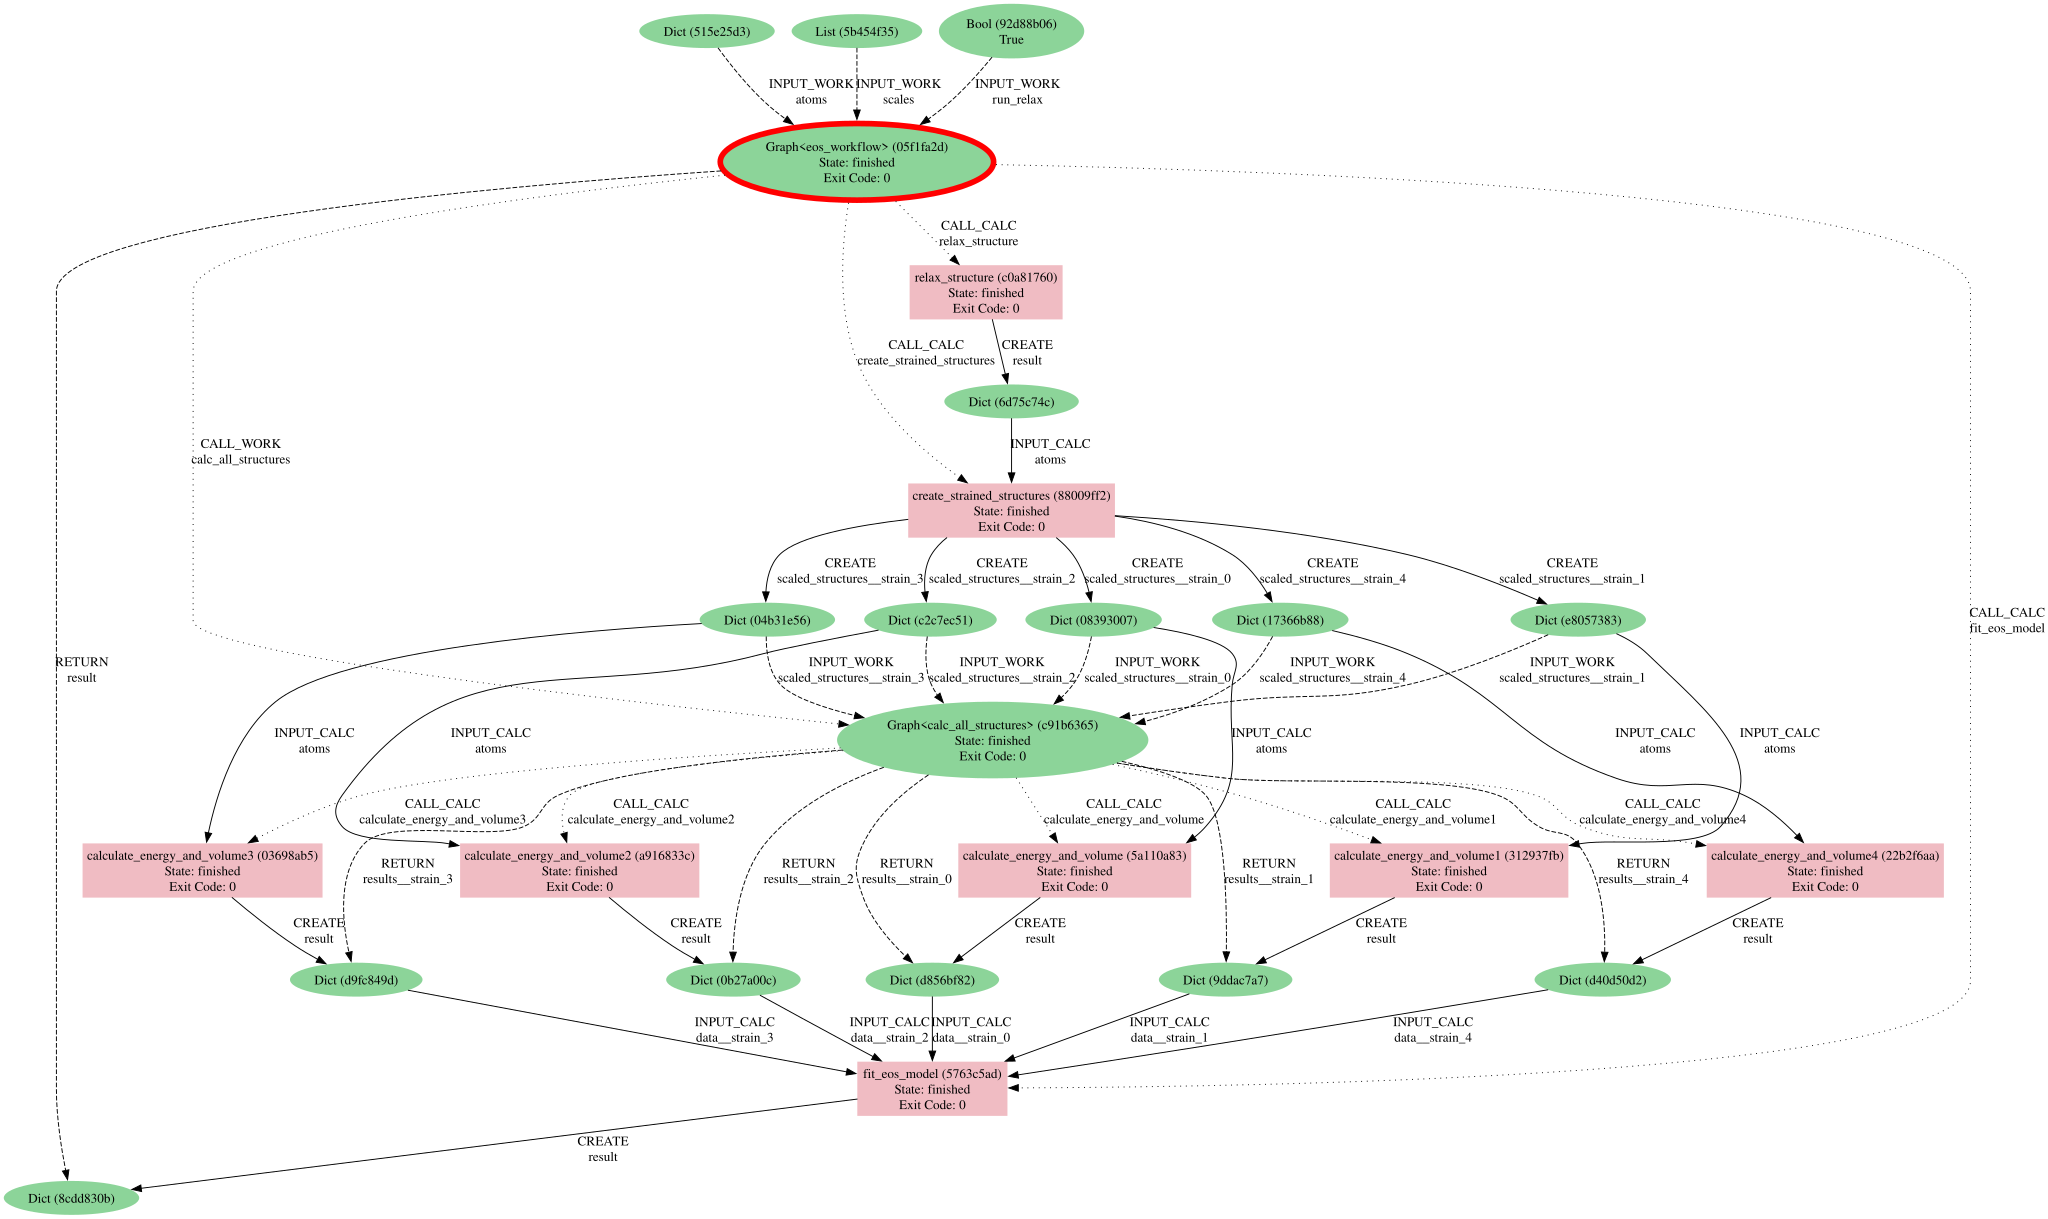

In [3]:
from node_graph_engine.engines.local import LocalEngine

engine = LocalEngine("eos_workflow_local")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Dask engine



      Step     Time          Energy          fmax
BFGS:    0 14:09:25       -0.006689        0.000000
Calculating energy and volume...
Calculating energy and volume...
Calculating energy and volume...
Calculating energy and volume...
Calculating energy and volume...
Fitted EOS parameters: {'result': <Dict: uuid: 8c9c7484-8b74-42c9-8f1c-d64bc330a763 (pk: 220289)>}


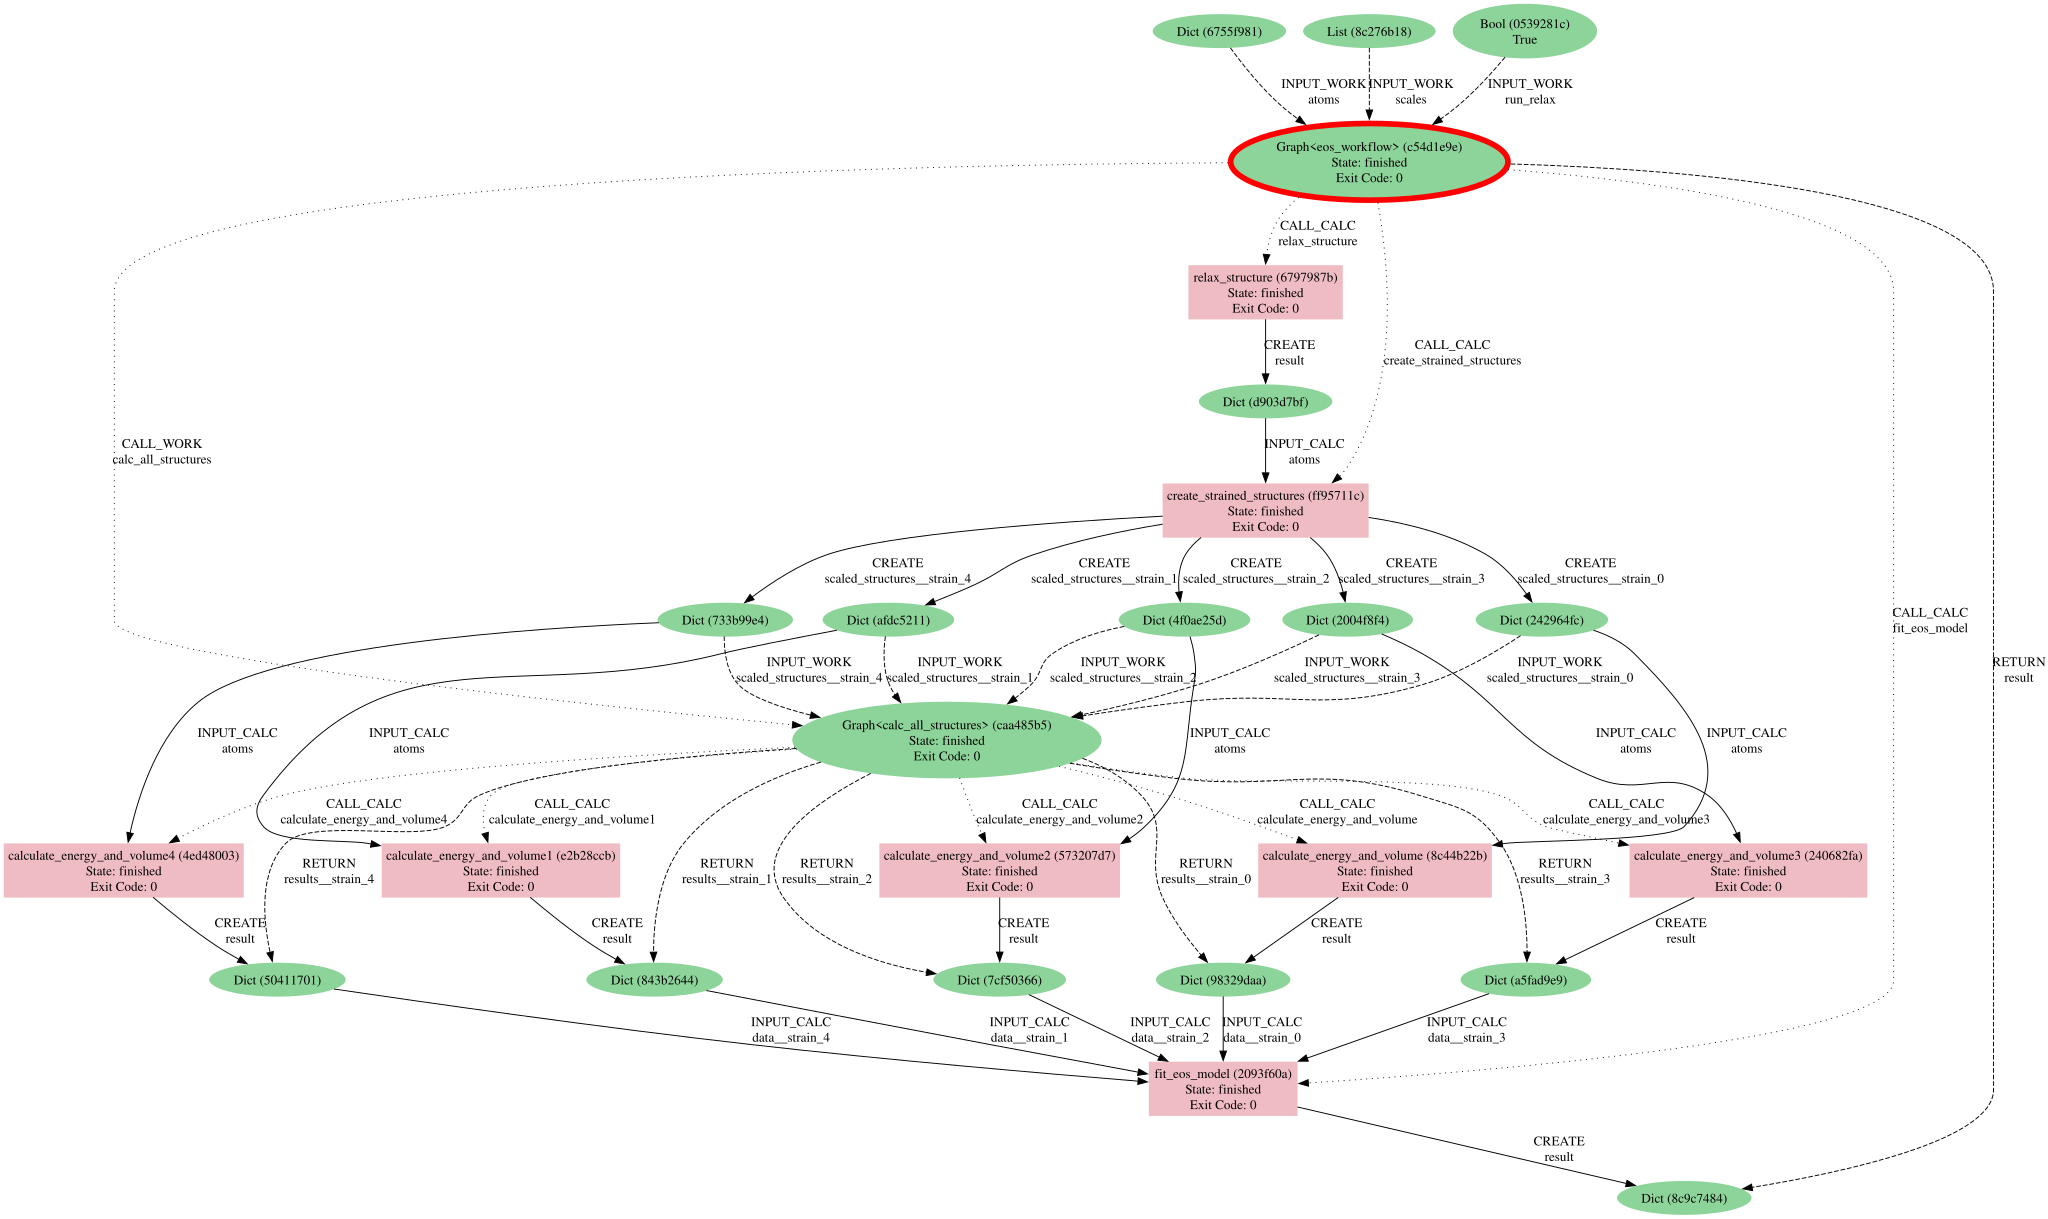

In [4]:
engine = DaskEngine("eos_workflow_dask")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Prefect engine



14:09:34.580 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8614
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

/home/xing/apps/miniforge3/envs/aiida/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'default' attribute with value 'UTC' was provided to the `Field()` function, which has no effect in the context it was used. 'default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(


14:09:40.509 | INFO    | Flow run 'omniscient-magpie' - Beginning flow run 'omniscient-magpie' for flow 'eos_workflow_prefect'

      Step     Time          Energy          fmax
BFGS:    0 14:09:40       -0.006689        0.000000


14:09:40.995 | INFO    | Task run 'task:relax_structure-354' - Finished in state Completed()

...

14:09:43.495 | INFO    | Task run 'task:calc_all_structures-6b6' - Finished in state Completed()

14:09:43.508 | INFO    | Task run 'ng:get_nested-ed9' - Finished in state Completed()

14:09:43.847 | INFO    | Task run 'task:fit_eos_model-75a' - Finished in state Completed()

14:09:43.892 | INFO    | Flow run 'omniscient-magpie' - Finished in state Completed()

state_map: {'graph_inputs': {'atoms': {'__ng_tagged__': True, 'uuid': 'cb3b6e2b-c6c2-4efb-ab3f-4d77b94eeb16'}, 'scales': {'__ng_tagged__': True, 'uuid': '60a379db-5640-4b41-8384-02f545312fbc'}, 'run_relax': {'__ng_tagged__': True, 'uuid': '98ea8b8e-b35c-4140-a710-03a30b24145d'}}, 'relax_structure': Completed(message=None, type=COMPLETED, result=ResultRecord(metadata=ResultRecordMetadata(storage_key='/home/xing/.prefect/storage/72546c500e394e5c85bb4c7853a86f38', expiration=None, serializer=PickleSerializer(type='pickle', picklelib='cloudpickle', picklelib_version=None), prefect_version='3.4.23', storage_block_id=None), result={'result': {'__ng_tagged__': True, 'uuid': 'f5876b13-de5d-4b92-905a-c10a6fb975ca'}})), 'create_strained_structures': Completed(message=None, type=COMPLETED, result=ResultRecord(metadata=ResultRecordMetadata(storage_key='/home/xing/.prefect/storage/d35c0057b50c46b794a23f52d586fe64', expiration=None, serializer=PickleSerializer(type='pickle', picklelib='cloudpickle',

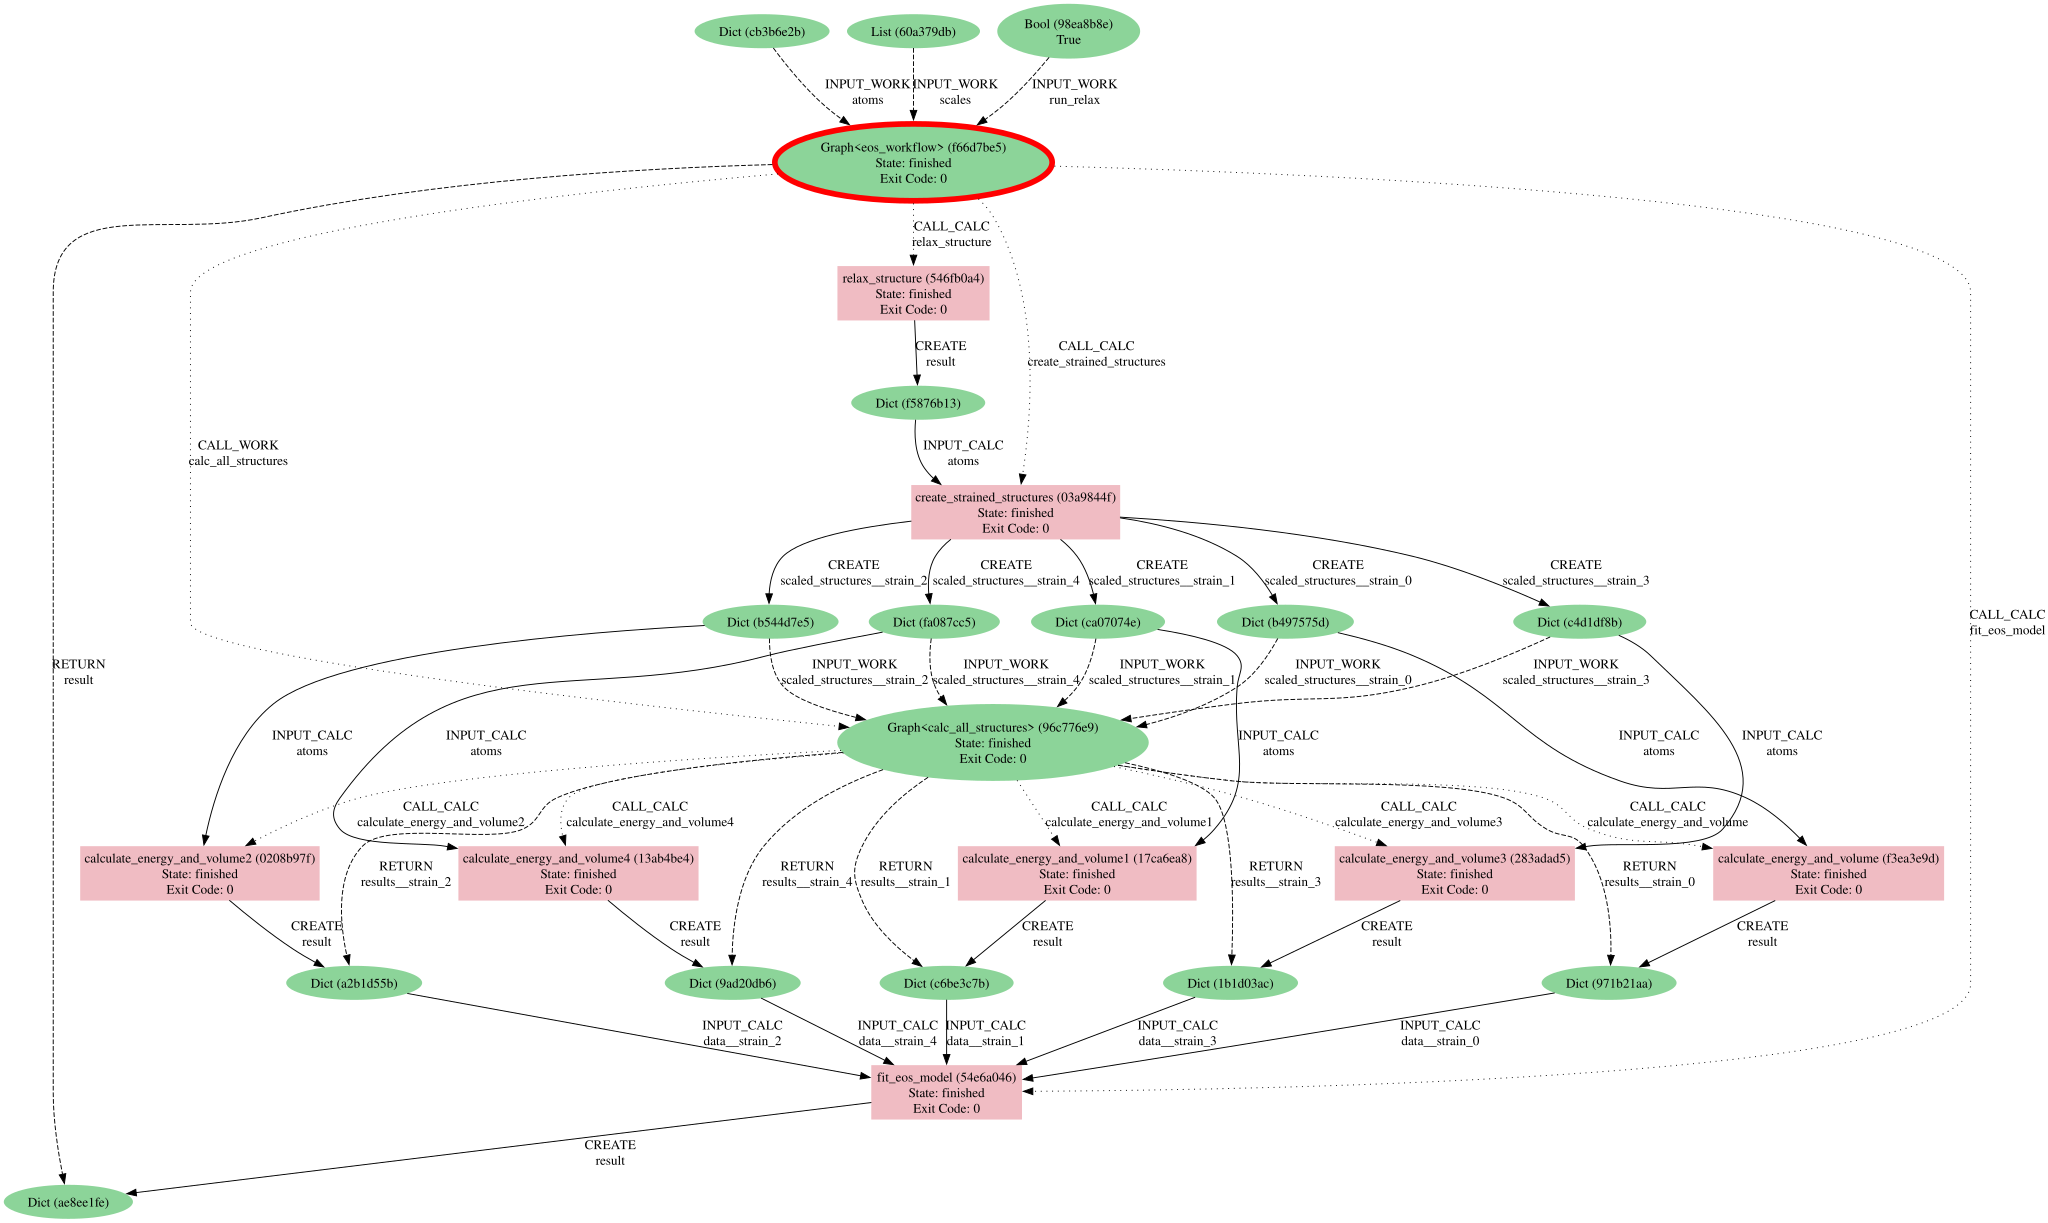

In [5]:
from node_graph_engine.engines.prefect import PrefectEngine

engine = PrefectEngine("eos_workflow_prefect")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Airflow engine



2025-11-27T13:09:45.796876Z [info     ] Waiting for Airflow scheduler to parse DAG 'eos_workflow_airflow' located at '/home/xing/airflow/dags/eos_workflow_airflow.py' [node_graph_engine.engines.airflow] loc=airflow.py:786


2025-11-27T13:09:45.797905Z [info     ] Filling up the DagBag from /home/xing/airflow/dags [airflow.models.dagbag.DagBag] loc=dagbag.py:593


2025-11-27T13:09:45.931668Z [info     ] DagBag detected DAG 'eos_workflow_airflow' after 1 attempt(s) [node_graph_engine.engines.airflow] loc=airflow.py:786


2025-11-27T13:09:45.932635Z [info     ] Filling up the DagBag from /home/xing/airflow/dags [airflow.models.dagbag.DagBag] loc=dagbag.py:593


2025-11-27T13:09:46.195489Z [info     ] Trigger attempt 1 for DAG 'eos_workflow_airflow' failed (Dag id eos_workflow_airflow not found in DagModel); retrying in 5.0s [node_graph_engine.engines.airflow] loc=airflow.py:661
2025-11-27T13:09:51.198159Z [info     ] Trigger attempt 2 for DAG 'eos_workflow_airflow' failed (Dag id eos_workflow_airflow not found in DagModel); retrying in 5.0s [node_graph_engine.engines.airflow] loc=airflow.py:661
2025-11-27T13:09:56.202035Z [info     ] Trigger attempt 3 for DAG 'eos_workflow_airflow' failed (Dag id eos_workflow_airflow not found in DagModel); retrying in 5.0s [node_graph_engine.engines.airflow] loc=airflow.py:661
2025-11-27T13:10:01.206584Z [info     ] Trigger attempt 4 for DAG 'eos_workflow_airflow' failed (Dag id eos_workflow_airflow not found in DagModel); retrying in 5.0s [node_graph_engine.engines.airflow] loc=airflow.py:661
2025-11-27T13:10:06.262476Z [info     ] Successfully triggered DAG 'eos_workflow_airflow' after 5 attempt(s) [node_g

Fitted EOS parameters: {'result': <Dict: uuid: 6e5ce806-19ee-473e-8fbc-bbde60d9361a (pk: 220339)>}


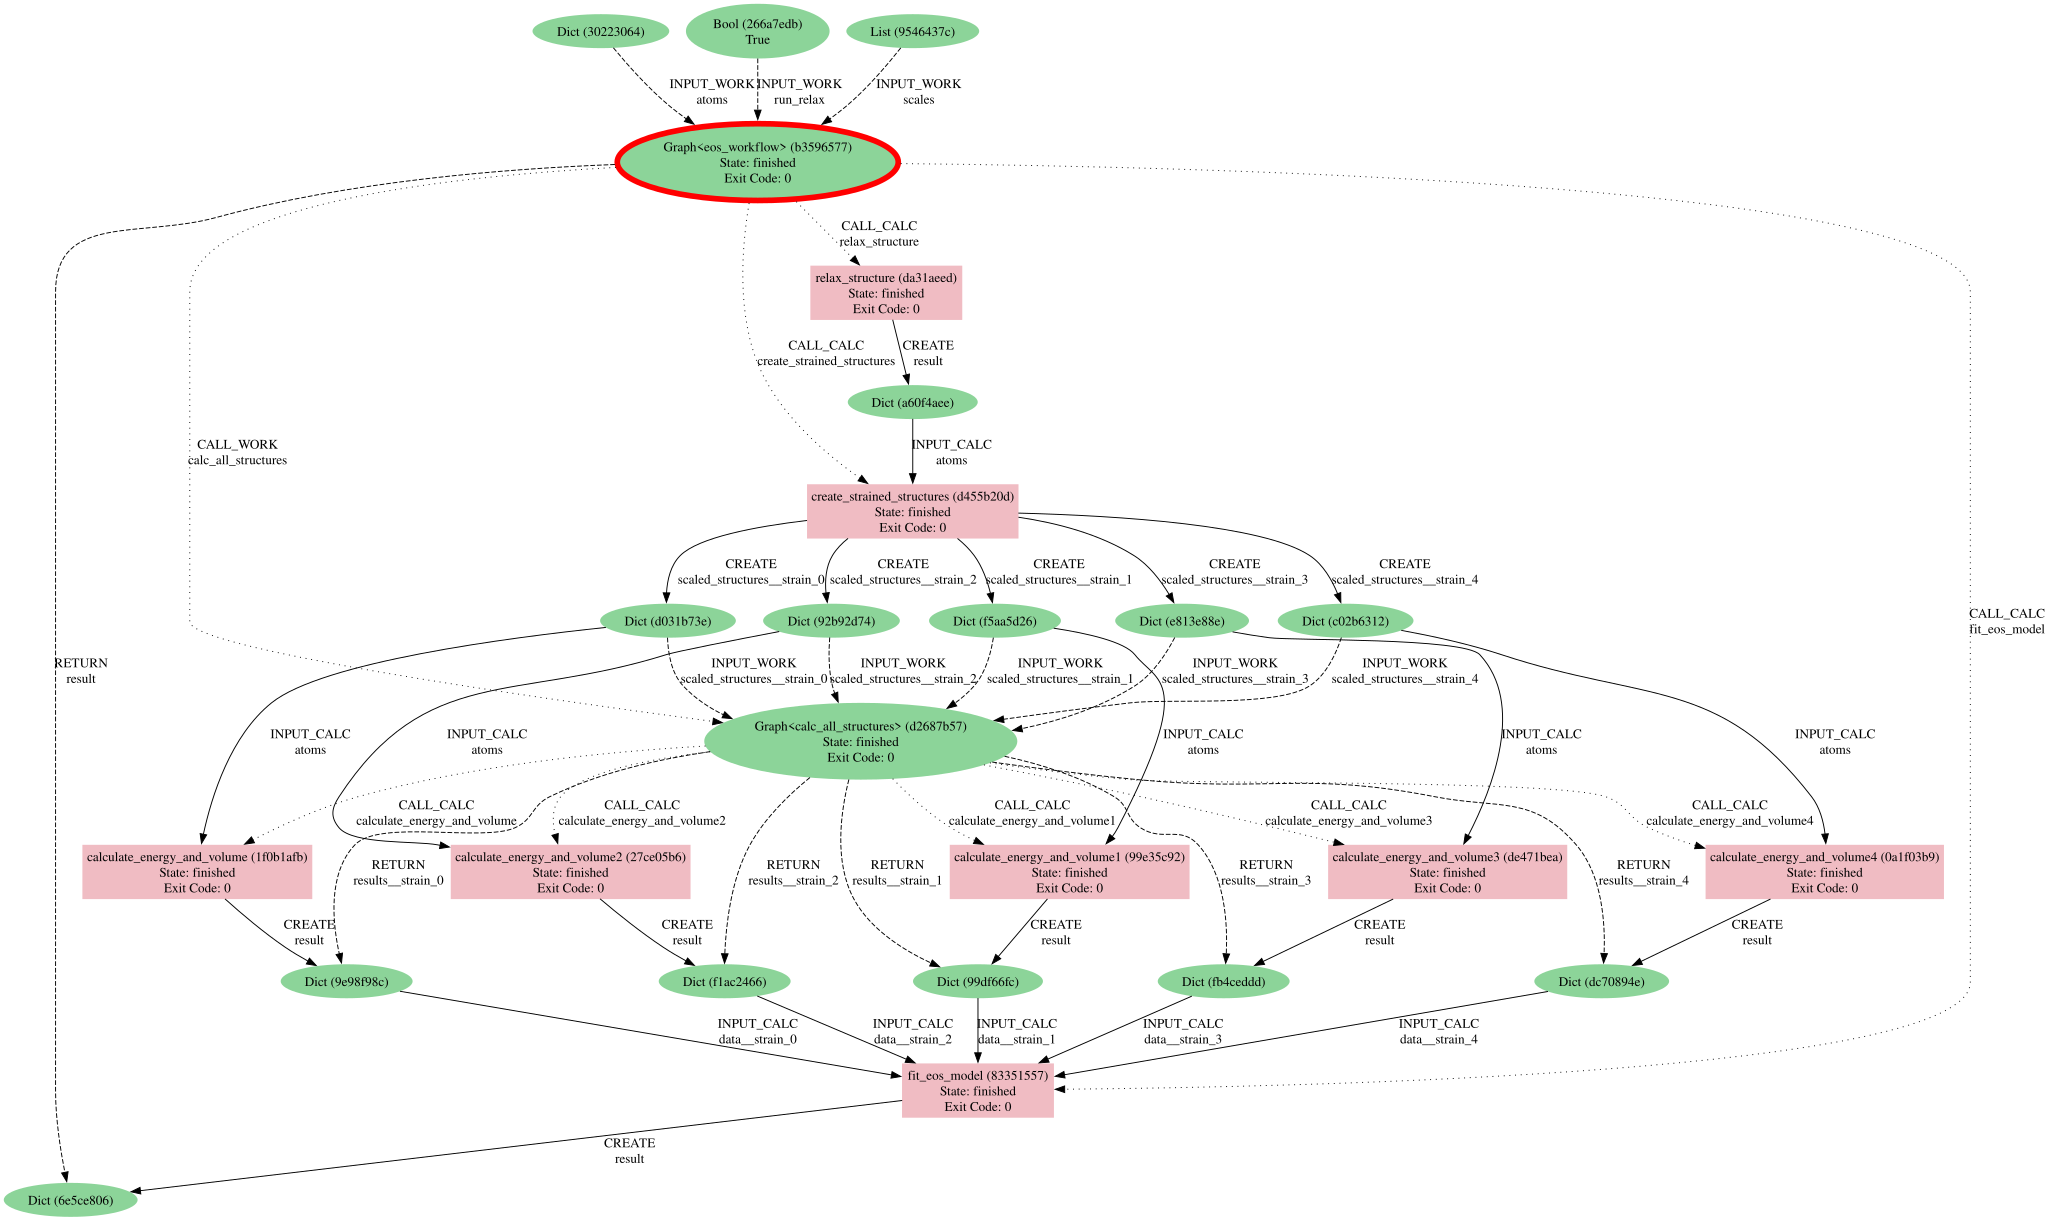

In [6]:
from node_graph_engine.engines.airflow import AirflowEngine

engine = AirflowEngine("eos_workflow_airflow")
results = engine.submit(ng, wait=True)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Celery engine



Fitted EOS parameters: {'result': <Dict: uuid: 91370dc4-33ca-4f41-8656-895f96eceed6 (pk: 220487)>}


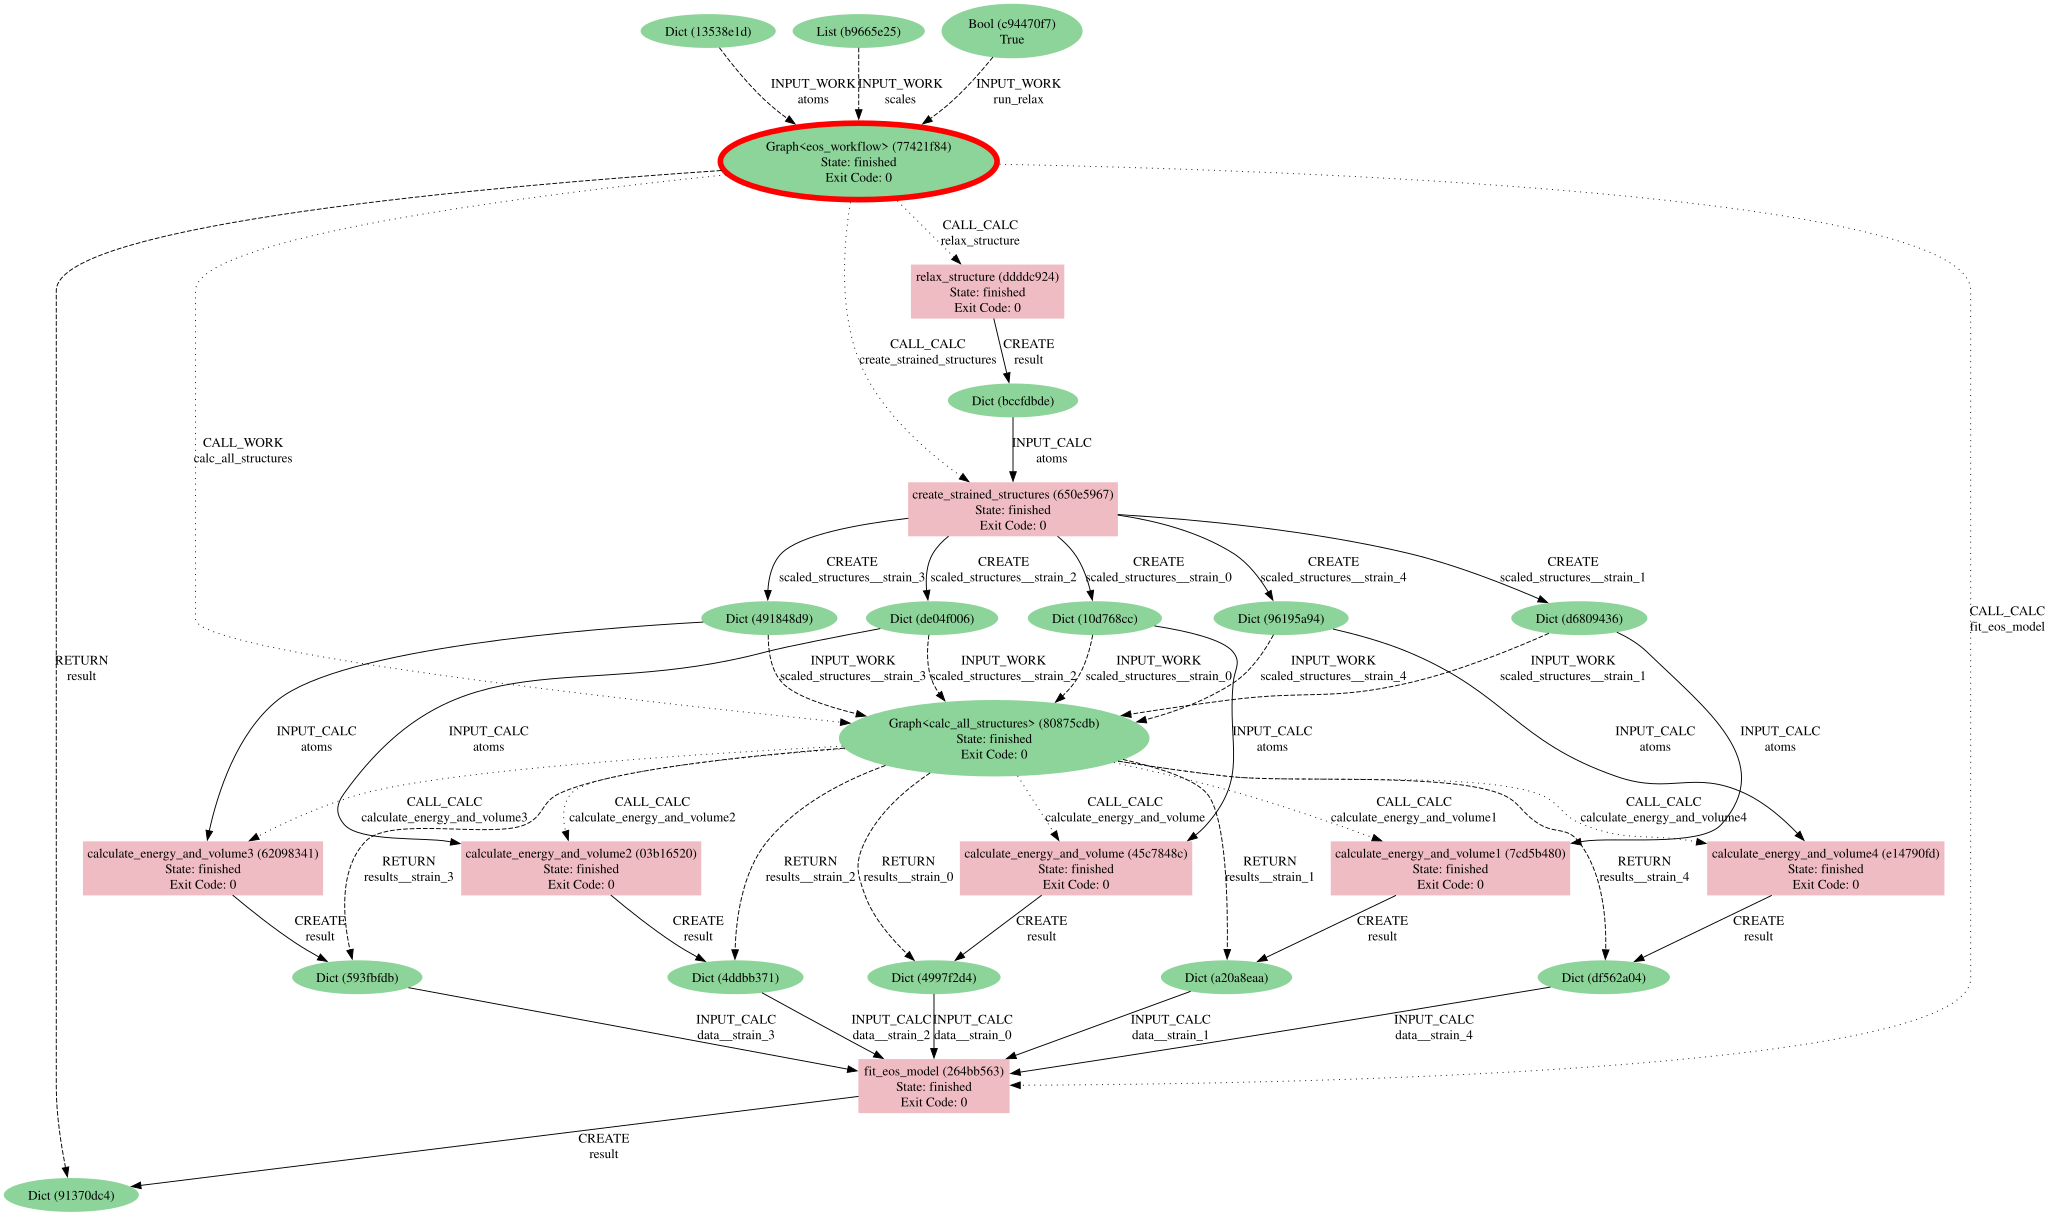

In [4]:
from node_graph_engine.engines.celery import CeleryEngine

engine = CeleryEngine(
    "celery-flow",
    broker_url="redis://localhost:6379/0",
    backend_url="redis://localhost:6379/1",
)
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Parsl engine



2025-11-27T13:11:25.360479Z [info     ] Starting DataFlowKernel with config
Config(
    app_cache=True, 
    checkpoint_files=None, 
    checkpoint_mode=None, 
    checkpoint_period=None, 
    dependency_resolver=None, 
    executors=(ThreadPoolExecutor(
        label='threads', 
        max_threads=4, 
        remote_monitoring_radio=<parsl.monitoring.radios.multiprocessing.MultiprocessingQueueRadio object at 0x7a1c2664c9d0>, 
        storage_access=None, 
        thread_name_prefix='', 
        working_dir=None
    ),), 
    exit_mode='cleanup', 
    garbage_collect=True, 
    initialize_logging=True, 
    internal_tasks_max_threads=10, 
    max_idletime=120.0, 
    monitoring=None, 
    project_name=None, 
    retries=0, 
    retry_handler=None, 
    run_dir='runinfo', 
    std_autopath=None, 
    strategy=None, 
    strategy_period=5, 
    usage_tracking=0
) [parsl.dataflow.dflow] loc=dflow.py:100
2025-11-27T13:11:25.361086Z [info     ] Parsl version: 2025.10.06      [parsl.dataflo

      Step     Time          Energy          fmax
BFGS:    0 14:11:25       -0.006689        0.000000


2025-11-27T13:11:25.761631Z [info     ] Task 0 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:25.762498Z [info     ] Standard out for task 0 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:25.763148Z [info     ] Standard error for task 0 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:25.763695Z [info     ] Parsl task 1 try 0 launched on executor threads [parsl.dataflow.dflow] loc=dflow.py:775
2025-11-27T13:11:25.764279Z [info     ] Standard out for task 1 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:25.764732Z [info     ] Standard error for task 1 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:25.765339Z [info     ] Task 1 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:25.765840Z [info     ] Standard out for task 1 will not be redirected. [parsl.dataflow.dflow]

Calculating energy and volume...
Calculating energy and volume...


2025-11-27T13:11:26.721321Z [info     ] Task 8 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:26.722750Z [info     ] Standard out for task 8 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:26.729157Z [info     ] Standard error for task 8 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:26.763788Z [info     ] Task 7 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:26.764608Z [info     ] Standard out for task 7 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:26.765059Z [info     ] Standard error for task 7 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339


Calculating energy and volume...


2025-11-27T13:11:26.953982Z [info     ] Task 9 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:26.956287Z [info     ] Standard out for task 9 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:26.960403Z [info     ] Standard error for task 9 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339


Calculating energy and volume...
Calculating energy and volume...


2025-11-27T13:11:27.180853Z [info     ] Task 10 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:27.183076Z [info     ] Standard out for task 10 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:27.186605Z [info     ] Standard error for task 10 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:27.189446Z [info     ] Task 11 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:27.191265Z [info     ] Standard out for task 11 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:27.203158Z [info     ] Standard error for task 11 will not be redirected. [parsl.dataflow.dflow] loc=dflow.py:1339
2025-11-27T13:11:27.401958Z [info     ] Task 4 completed (launched -> exec_done) [parsl.dataflow.dflow] loc=dflow.py:593
2025-11-27T13:11:27.402745Z [info     ] Standard out for task 4 will not be redirected. [parsl.dataflow.dflow] 

Fitted EOS parameters: {'result': <Dict: uuid: 58ab0e3f-d0b0-47c3-843c-52ff53304c81 (pk: 220364)>}


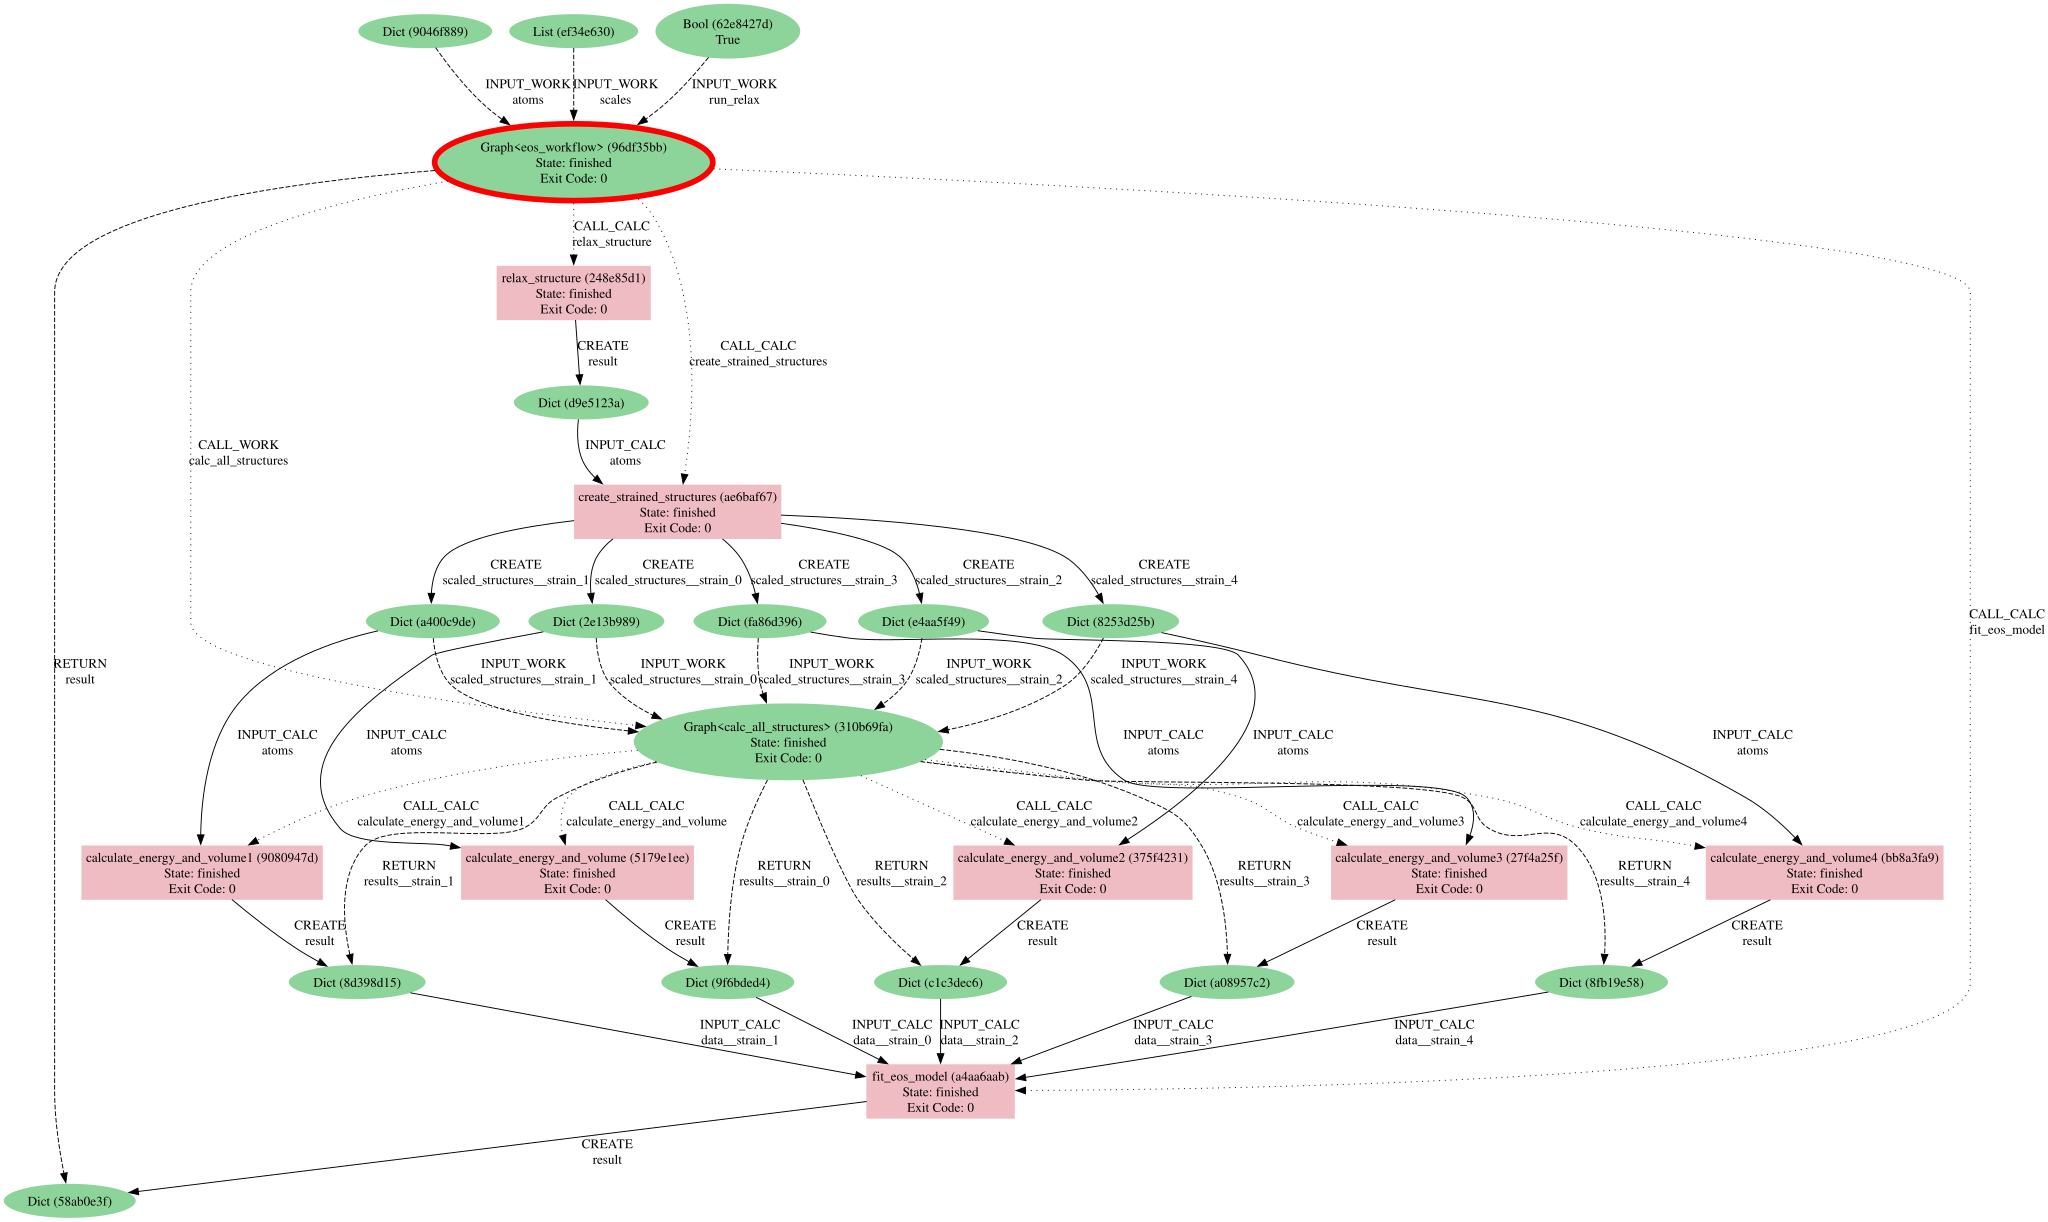

In [8]:
engine = ParslEngine("eos_workflow_parsl")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Jobflow engine



2025-11-27 14:11:33,277 INFO Started executing jobs locally


2025-11-27T13:11:33.278465Z [info     ] Started executing jobs locally [jobflow.managers.local] loc=local.py:179


2025-11-27 14:11:33,482 INFO Starting job - relax_structure (47622e37-a333-403c-9bc2-aace79cc290a)


2025-11-27T13:11:33.483684Z [info     ] Starting job - relax_structure (47622e37-a333-403c-9bc2-aace79cc290a) [jobflow.core.job] loc=job.py:586


      Step     Time          Energy          fmax
BFGS:    0 14:11:33       -0.006689        0.000000
2025-11-27 14:11:33,651 INFO Finished job - relax_structure (47622e37-a333-403c-9bc2-aace79cc290a)


...

2025-11-27 14:11:35,296 INFO Finished job - fit_eos_model (7746440f-c13d-4fd6-8ccf-39ffe0f46da9)


2025-11-27T13:11:35.297055Z [info     ] Finished job - fit_eos_model (7746440f-c13d-4fd6-8ccf-39ffe0f46da9) [jobflow.core.job] loc=job.py:673


2025-11-27 14:11:35,297 INFO Finished executing jobs locally


2025-11-27T13:11:35.297954Z [info     ] Finished executing jobs locally [jobflow.managers.local] loc=local.py:181


Fitted EOS parameters: {'result': <Dict: uuid: e197083f-a464-48ce-8645-32de535d4aad (pk: 220389)>}


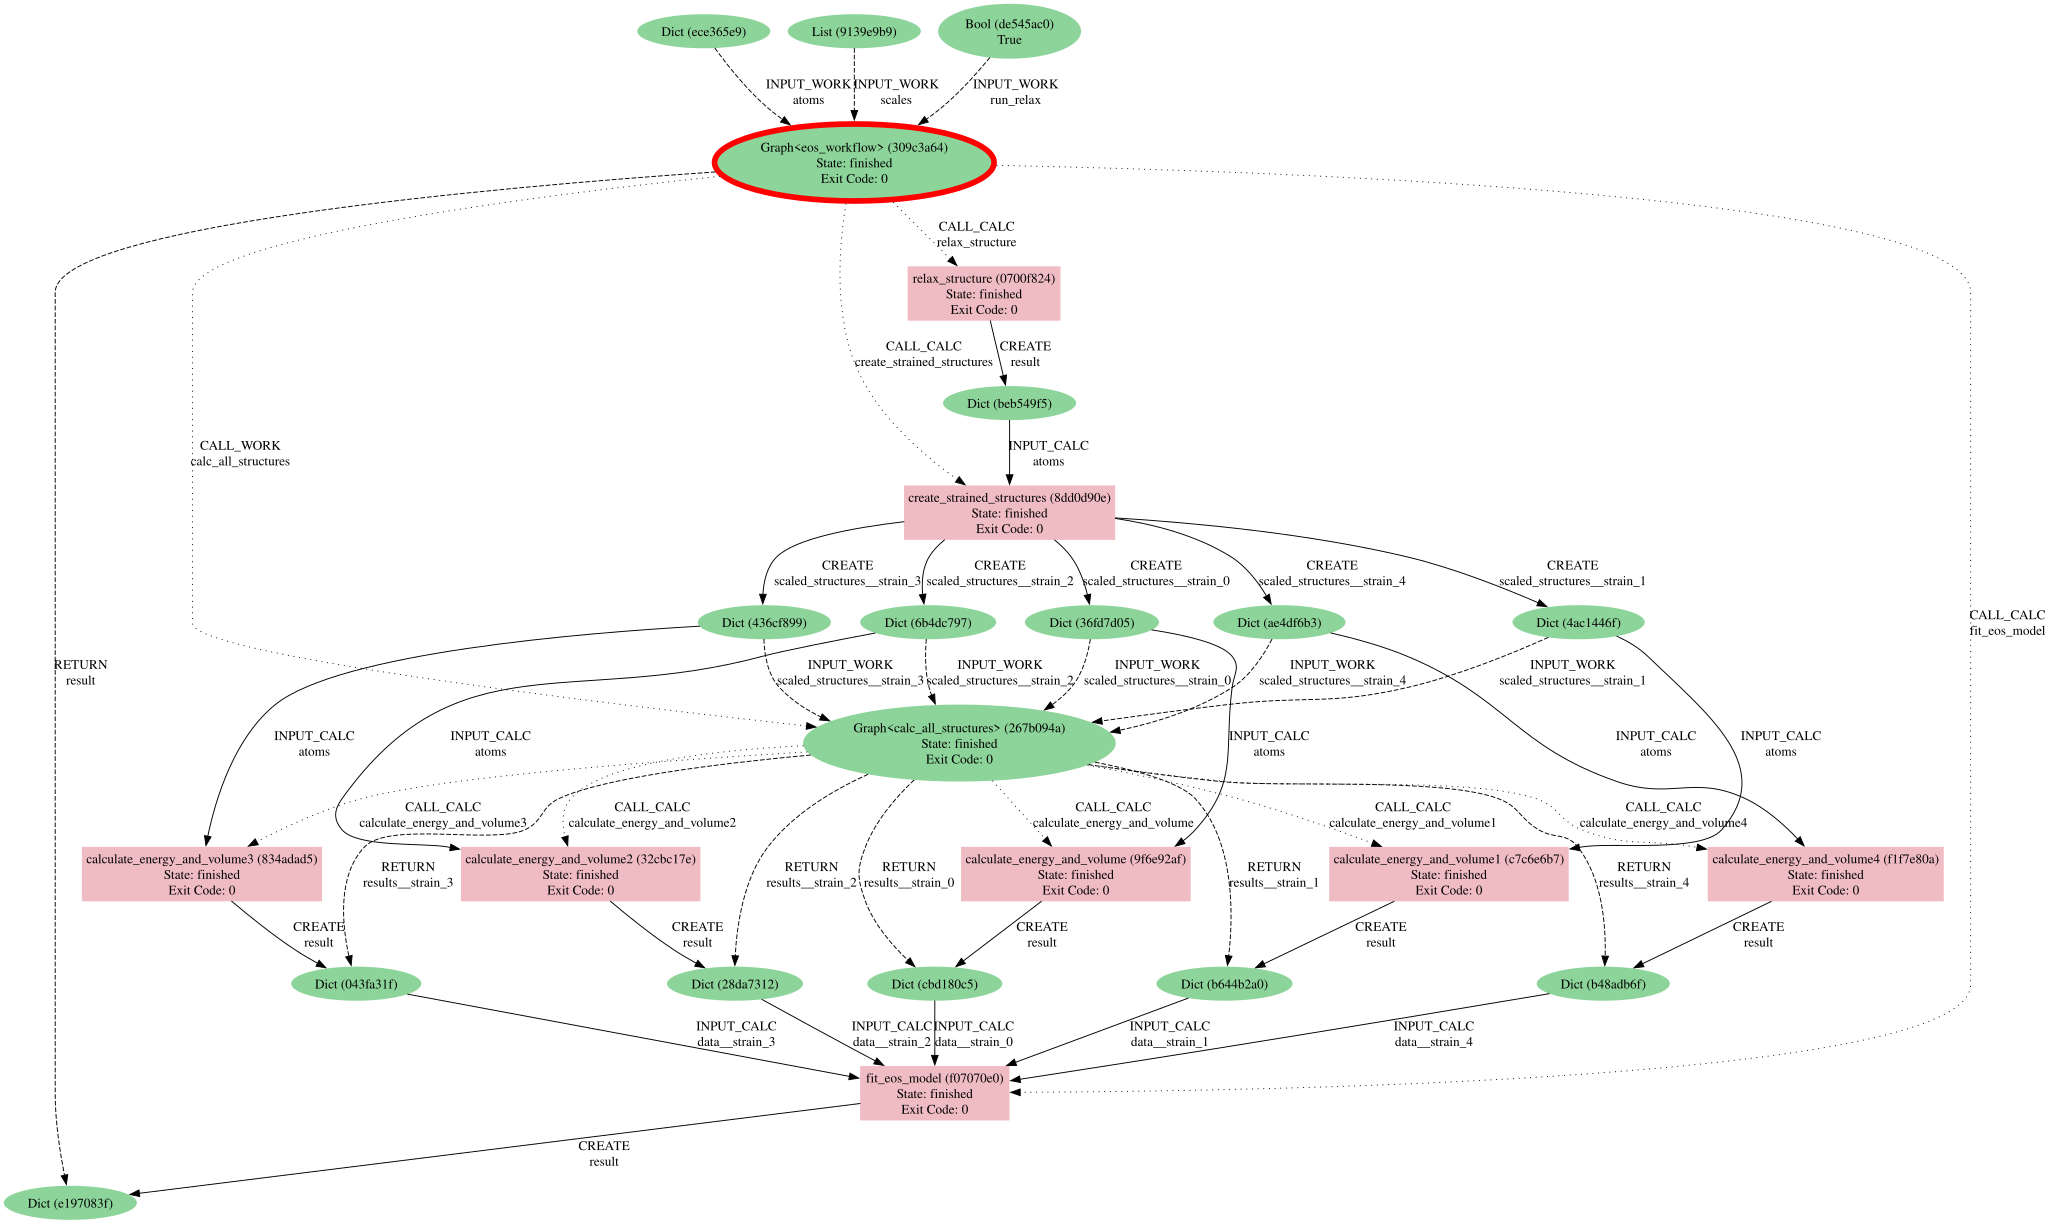

In [9]:
from node_graph_engine.engines.jobflow import JobflowEngine

engine = JobflowEngine("eos_workflow_jobflow")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Executorlib (pyiron) engine



      Step     Time          Energy          fmax
BFGS:    0 14:11:43       -0.006689        0.000000
Calculating energy and volume...
Calculating energy and volume...
Calculating energy and volume...
Calculating energy and volume...
Calculating energy and volume...
Fitted EOS parameters: {'result': <Dict: uuid: 484c7376-5ab7-4394-9205-ab60e40b7f1c (pk: 220414)>}


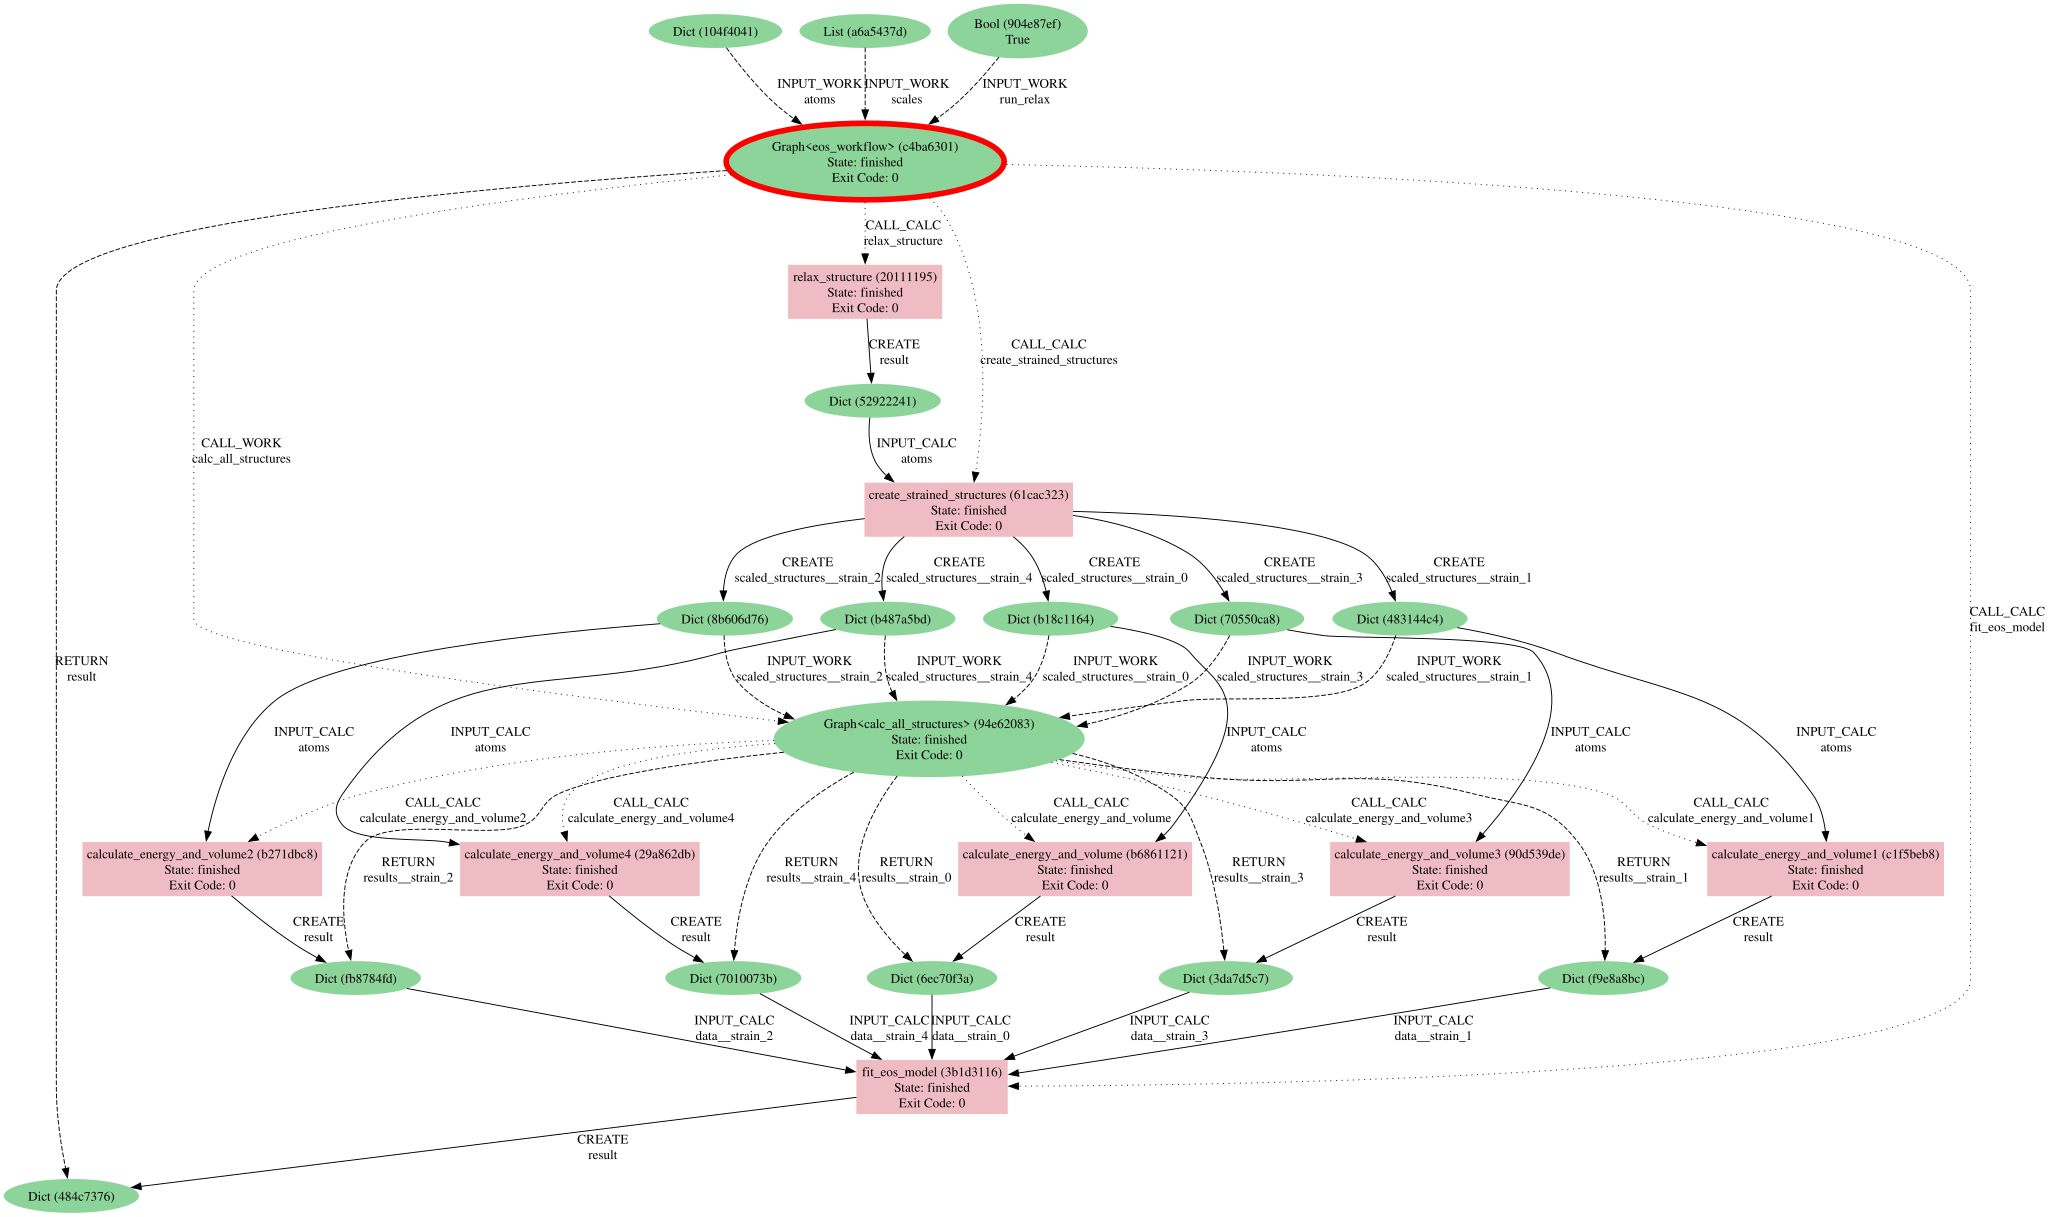

In [10]:
from node_graph_engine.engines.executorlib import ExecutorlibEngine

engine = ExecutorlibEngine("eos_workflow_executorlib")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Dagster engine



No dagster instance configuration file (dagster.yaml) found at /tmp/tmp2gc70l5o. Defaulting to loading and storing all metadata with /tmp/tmp2gc70l5o. If this is the desired behavior, create an empty dagster.yaml file in /tmp/tmp2gc70l5o.
No dagster instance configuration file (dagster.yaml) found at /tmp/tmp2gc70l5o. Defaulting to loading and storing all metadata with /tmp/tmp2gc70l5o. If this is the desired behavior, create an empty dagster.yaml file in /tmp/tmp2gc70l5o.
2025-11-27 14:14:00 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - RUN_START - Started execution of run for "eos_workflow_dagster".
2025-11-27 14:14:00 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - ENGINE_EVENT - Executing steps in process (pid: 1072455)
2025-11-27 14:14:00 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - RESOURCE_INIT_STARTED - Starting initializatio

      Step     Time          Energy          fmax
BFGS:    0 14:14:00       -0.006689        0.000000


2025-11-27 14:14:01 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - relax_structure - STEP_OUTPUT - Yielded output "result" of type "Any". (Type check passed).
2025-11-27 14:14:01 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - relax_structure - HANDLED_OUTPUT - Handled output "result" using IO manager "io_manager"
2025-11-27 14:14:01 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - relax_structure - STEP_SUCCESS - Finished execution of step "relax_structure" in 137ms.
2025-11-27 14:14:01 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - create_strained_structures - STEP_START - Started execution of step "create_strained_structures".
2025-11-27 14:14:01 +0100 - dagster - DEBUG - eos_workflow_dagster - 5198a545-bb84-4449-a1b5-c2f8ace657c2 - 1072455 - create_strained_structures - LOADED_INPUT -

Calculating energy and volume...
Calculating energy and volume...


2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume1 - STEP_OUTPUT - Yielded output "result" of type "Any". (Type check passed).
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume1 - HANDLED_OUTPUT - Handled output "result" using IO manager "io_manager"
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume1 - STEP_SUCCESS - Finished execution of step "calculate_energy_and_volume1" in 166ms.
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume2 - STEP_START - Started execution of step "calculate_energy_and_volume2".
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 10

Calculating energy and volume...
Calculating energy and volume...


2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume3 - STEP_OUTPUT - Yielded output "result" of type "Any". (Type check passed).
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume3 - HANDLED_OUTPUT - Handled output "result" using IO manager "io_manager"
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume3 - STEP_SUCCESS - Finished execution of step "calculate_energy_and_volume3" in 182ms.
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - calculate_energy_and_volume4 - STEP_START - Started execution of step "calculate_energy_and_volume4".
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 10

Calculating energy and volume...


2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - engine__finalize - LOADED_INPUT - Loaded input "node_4" using input manager "io_manager", from output "result" of step "calculate_energy_and_volume4"
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - engine__finalize - STEP_INPUT - Got input "engine_context" of type "Any". (Type check passed).
2025-11-27 14:14:02 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - engine__finalize - STEP_INPUT - Got input "node_0" of type "Any". (Type check passed).
2025-11-27 14:14:03 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 1072455 - engine__finalize - STEP_INPUT - Got input "node_1" of type "Any". (Type check passed).
2025-11-27 14:14:03 +0100 - dagster - DEBUG - calc_all_structures - 38664681-c56a-4982-b953-f182cc9177fc - 107245

Fitted EOS parameters: {'result': <Dict: uuid: 96792910-5dd6-4521-bf3e-0897f3ca2416 (pk: 220512)>}


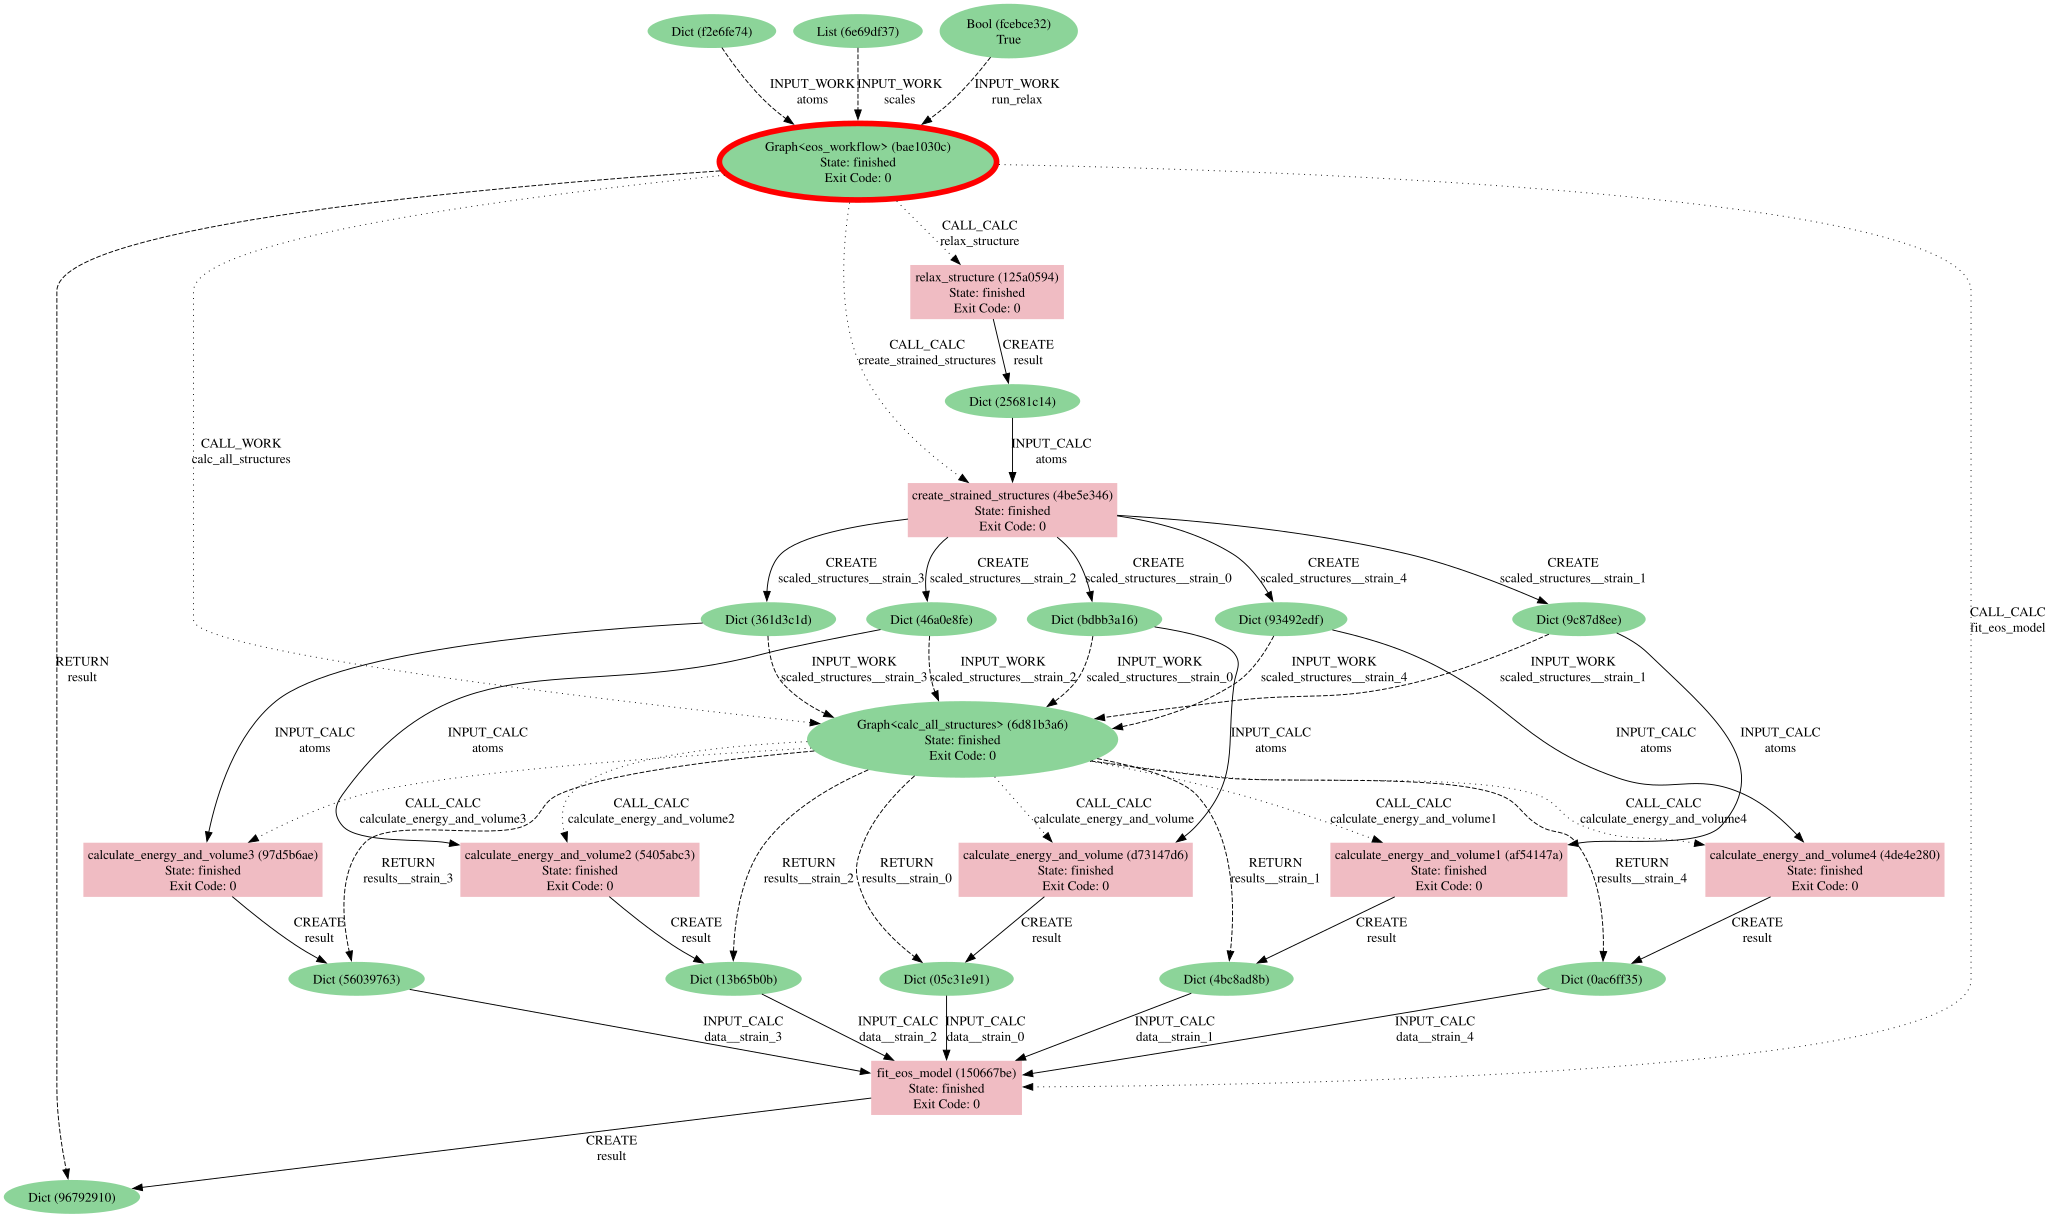

In [5]:
from node_graph_engine.engines.dagster import DagsterEngine

engine = DagsterEngine("eos_workflow_dagster")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

## Redun engine



[redun] Upgrading db from version -1.0 to 3.5...
2025-11-27T13:12:18.435077Z [info     ] Upgrading db from version -1.0 to 3.5... [redun] loc=__init__.py:1663
[redun] Start Execution 4e88eb48-1f64-44a8-a741-a97c7435a215:  redun 'redun.root_task(QuotedExpression(ng_bundle(calc_all_structures=task_eos_workflow_redun_calc_all_structures(_ng_callable={'"'"'mode'"'"': '"'"'pickled_callable'"'"', '"'"'module_path'"'"': None, '"'"'callable_name'"'"': '"'"'calc_all_...'
2025-11-27T13:12:18.682346Z [info     ] Start Execution 4e88eb48-1f64-44a8-a741-a97c7435a215:  redun 'redun.root_task(QuotedExpression(ng_bundle(calc_all_structures=task_eos_workflow_redun_calc_all_structures(_ng_callable={'"'"'mode'"'"': '"'"'pickled_callable'"'"', '"'"'module_path'"'"': None, '"'"'callable_name'"'"': '"'"'calc_all_...' [redun] loc=scheduler.py:1028
[redun] Tasks will require namespace soon. Either set namespace in the `@task` decorator or with the module-level variable `redun_namespace`.
tasks needing namespa

self.instance: QuotedExpression(ng_bundle(calc_all_structures=task_eos_workflow_redun_calc_all_structures(_ng_callable={'mode': 'pickled_callable', 'module_path': None, 'callable_name': 'calc_all_structures', 'callable_kind': None, 'graph_data': None, 'pickled_callable': 'gAWVMhUAAAAAAACMF2Nsb3VkcGlja2xlLmNsb3VkcGlja2xllIwOX21ha2VfZnVuY3Rpb26Uk5QoaACMDV9idWlsdGluX3R5cGWUk5SMCENvZGVUeXBllIWUUpQoSwFLAEsASwRLBEsDQ3CXAGkAfQF8AKAAAAAAAAAAAAAAAAAAAAAAAAAAAACmAAAAqwAAAAAAAAAAAEQAXRxcAgAAfQJ9A3QDAAAAAAAAAAAAAHwDpgEAAKsBAAAAAAAAAABqAgAAAAAAAAAAfAF8AjwAAACMHWQBfAFpAVMAlIxUU3ViLXdvcmtmbG93IHRvIGNhbGN1bGF0ZSBlbmVyZ3kgYW5kIHZvbHVtZSBmb3IgYWxsIHN0cmFpbmVkIHN0cnVjdHVyZXMgaW4gcGFyYWxsZWwulIwHcmVzdWx0c5SGlIwFaXRlbXOUjBtjYWxjdWxhdGVfZW5lcmd5X2FuZF92b2x1bWWUjAZyZXN1bHSUh5QojBFzY2FsZWRfc3RydWN0dXJlc5RoCowDa2V5lIwFYXRvbXOUdJSMIy90bXAvaXB5a2VybmVsXzEwNjYyNDcvNTg1MDgxMDY2LnB5lIwTY2FsY19hbGxfc3RydWN0dXJlc5SME2NhbGNfYWxsX3N0cnVjdHVyZXOUSzpDT4AA8AoADxGAR9gWJ9cWLdIWLdEWL9QWL/AAAwVBAfAAAwVBAYkKiAOIVfUGABgzsDXRFzn

[redun] Run    Job 43e3d290:  ng_get_nested(d={'result': {'__ng_tagged__': True, 'uuid': '456ddfdb-1061-46e2-9d6e-84e69330be41'}}, dotted='result', default=None) on default
2025-11-27T13:12:18.810246Z [info     ] Run    Job 43e3d290:  ng_get_nested(d={'result': {'__ng_tagged__': True, 'uuid': '456ddfdb-1061-46e2-9d6e-84e69330be41'}}, dotted='result', default=None) on default [redun] loc=scheduler.py:1028
[redun] Run    Job bc93f60c:  task_eos_workflow_redun_create_strained_structures(parent_pid='e93e31a3-fc95-49fb-91b5-a6317632e360', _ng_meta=TaskMeta(node_name='create_strained_structures', outputs_spec={'identifier': 'node_graph.namespace', 'dynamic': False, 'fields': {'scaled_structures': {'identifier': 'node_graph.namespace', 'dynami..., _ng_callable={'mode': 'pickled_callable', 'module_path': None, 'callable_name': 'create_strained_structures', 'callable_kind': None, 'graph_data': None, 'pickled_callable': 'gAWVvQcAAAAAAACMF2Nsb3VkcGlja2xlLmNs..., _ng_engine_name='eos_workflow_redu

self.instance: {'result': {'__ng_tagged__': True, 'uuid': '456ddfdb-1061-46e2-9d6e-84e69330be41'}}
self.instance: result
self.instance: None
self.instance: e93e31a3-fc95-49fb-91b5-a6317632e360
self.instance: TaskMeta(node_name='create_strained_structures', outputs_spec={'identifier': 'node_graph.namespace', 'dynamic': False, 'fields': {'scaled_structures': {'identifier': 'node_graph.namespace', 'dynamic': True, 'item': {'identifier': 'node_graph.any', 'dynamic': False, 'meta': {'required': True, 'child_default_link_limit': 1}}, 'meta': {'required': True, 'child_default_link_limit': 1}}}, 'meta': {'required': True, 'call_role': <CallRole.RETURN: 'return'>, 'child_default_link_limit': 1}}, label_kind='create', is_graph=False, semantics=None)
self.instance: {'mode': 'pickled_callable', 'module_path': None, 'callable_name': 'create_strained_structures', 'callable_kind': None, 'graph_data': None, 'pickled_callable': 'gAWVvQcAAAAAAACMF2Nsb3VkcGlja2xlLmNsb3VkcGlja2xllIwOX21ha2VfZnVuY3Rpb26Uk5

[redun] Run    Job f365a719:  ng_get_nested(d={'scaled_structures': {'strain_0': {'__ng_tagged__': True, 'uuid': '4f3e6b25-587a-47e2-b414-badf3a887dc7'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '246576de-3e8c-4aab-b695-cfeb9bca8f59'}, 'str..., dotted='scaled_structures', default=None) on default
2025-11-27T13:12:19.059497Z [info     ] Run    Job f365a719:  ng_get_nested(d={'scaled_structures': {'strain_0': {'__ng_tagged__': True, 'uuid': '4f3e6b25-587a-47e2-b414-badf3a887dc7'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '246576de-3e8c-4aab-b695-cfeb9bca8f59'}, 'str..., dotted='scaled_structures', default=None) on default [redun] loc=scheduler.py:1028
[redun] Run    Job 04b0b5c9:  task_eos_workflow_redun_calc_all_structures(parent_pid='e93e31a3-fc95-49fb-91b5-a6317632e360', _ng_meta=TaskMeta(node_name='calc_all_structures', outputs_spec={'identifier': 'node_graph.namespace', 'dynamic': False, 'fields': {'results': {'identifier': 'node_graph.namespace', 'dynamic': True, 'item':..., 

...

self.instance: {'result': {'__ng_tagged__': True, 'uuid': '8706db7b-07ae-487f-9242-e2350f7b73a0'}}
self.instance: result
self.instance: None
self.instance: {'result': {'__ng_tagged__': True, 'uuid': 'fafa56c5-ba11-42da-9614-c188c8a54e6c'}}
self.instance: result
self.instance: None
self.instance: {'result': {'__ng_tagged__': True, 'uuid': '957dcfb4-f560-451f-95c8-ab5d00ce4a5e'}}
self.instance: result
self.instance: None
self.instance: {'result': {'__ng_tagged__': True, 'uuid': '4d2ed87f-5942-4379-adfa-94628c89c250'}}
self.instance: result
self.instance: None
self.instance: {'result': {'__ng_tagged__': True, 'uuid': 'fdbf7300-1b5c-4bd0-a146-2527f9afe14d'}}
self.instance: result
self.instance: None
self.instance: {'strain_0': {'__ng_tagged__': True, 'uuid': '4d2ed87f-5942-4379-adfa-94628c89c250'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '8706db7b-07ae-487f-9242-e2350f7b73a0'}, 'strain_2': {'__ng_tagged__': True, 'uuid': '957dcfb4-f560-451f-95c8-ab5d00ce4a5e'}, 'strain_3': {'__ng_tagge

[redun] Run    Job eaeb5aeb:  ng_get_nested(d={'results': {'strain_0': {'__ng_tagged__': True, 'uuid': '4d2ed87f-5942-4379-adfa-94628c89c250'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '8706db7b-07ae-487f-9242-e2350f7b73a0'}, 'strain_2': {'..., dotted='results', default=None) on default
2025-11-27T13:12:21.948924Z [info     ] Run    Job eaeb5aeb:  ng_get_nested(d={'results': {'strain_0': {'__ng_tagged__': True, 'uuid': '4d2ed87f-5942-4379-adfa-94628c89c250'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '8706db7b-07ae-487f-9242-e2350f7b73a0'}, 'strain_2': {'..., dotted='results', default=None) on default [redun] loc=scheduler.py:1028
[redun] Run    Job eb628285:  task_eos_workflow_redun_fit_eos_model(parent_pid='e93e31a3-fc95-49fb-91b5-a6317632e360', _ng_meta=TaskMeta(node_name='fit_eos_model', outputs_spec={'identifier': 'node_graph.namespace', 'dynamic': False, 'fields': {'result': {'identifier': 'node_graph.any', 'dynamic': False, 'meta': {'required'..., _ng_callable={'mode': 'pic

self.instance: {'results': {'strain_0': {'__ng_tagged__': True, 'uuid': '4d2ed87f-5942-4379-adfa-94628c89c250'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '8706db7b-07ae-487f-9242-e2350f7b73a0'}, 'strain_2': {'__ng_tagged__': True, 'uuid': '957dcfb4-f560-451f-95c8-ab5d00ce4a5e'}, 'strain_3': {'__ng_tagged__': True, 'uuid': 'fdbf7300-1b5c-4bd0-a146-2527f9afe14d'}, 'strain_4': {'__ng_tagged__': True, 'uuid': 'fafa56c5-ba11-42da-9614-c188c8a54e6c'}}}
self.instance: results
self.instance: None
self.instance: e93e31a3-fc95-49fb-91b5-a6317632e360
self.instance: TaskMeta(node_name='fit_eos_model', outputs_spec={'identifier': 'node_graph.namespace', 'dynamic': False, 'fields': {'result': {'identifier': 'node_graph.any', 'dynamic': False, 'meta': {'required': True, 'child_default_link_limit': 1}}}, 'meta': {'required': True, 'call_role': <CallRole.RETURN: 'return'>, 'child_default_link_limit': 1}}, label_kind='create', is_graph=False, semantics=None)
self.instance: {'mode': 'pickled_callable'

[redun] Run    Job ec73c80c:  ng_get_nested(d={'result': {'__ng_tagged__': True, 'uuid': '75ce8e6c-2337-4f88-aa1a-4794c09ea4a7'}}, dotted='result', default=None) on default
2025-11-27T13:12:22.306407Z [info     ] Run    Job ec73c80c:  ng_get_nested(d={'result': {'__ng_tagged__': True, 'uuid': '75ce8e6c-2337-4f88-aa1a-4794c09ea4a7'}}, dotted='result', default=None) on default [redun] loc=scheduler.py:1028
[redun] Run    Job 58b5a0e1:  ng_bundle(kwargs=<class 'inspect._empty'>) on default
2025-11-27T13:12:22.312528Z [info     ] Run    Job 58b5a0e1:  ng_bundle(kwargs=<class 'inspect._empty'>) on default [redun] loc=scheduler.py:1028
[redun] Run    Job 8c3f065c:  ng_bundle(kwargs=<class 'inspect._empty'>) on default
2025-11-27T13:12:22.321628Z [info     ] Run    Job 8c3f065c:  ng_bundle(kwargs=<class 'inspect._empty'>) on default [redun] loc=scheduler.py:1028
[redun] 
2025-11-27T13:12:22.332929Z [info     ]                                [redun] loc=scheduler.py:1028
[redun] | JOB STATUS 2

self.instance: {'result': {'__ng_tagged__': True, 'uuid': '75ce8e6c-2337-4f88-aa1a-4794c09ea4a7'}}
self.instance: result
self.instance: None
self.instance: {'__ng_tagged__': True, 'uuid': '75ce8e6c-2337-4f88-aa1a-4794c09ea4a7'}
self.instance: {'result': {'__ng_tagged__': True, 'uuid': '456ddfdb-1061-46e2-9d6e-84e69330be41'}}
self.instance: {'scaled_structures': {'strain_0': {'__ng_tagged__': True, 'uuid': '4f3e6b25-587a-47e2-b414-badf3a887dc7'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '246576de-3e8c-4aab-b695-cfeb9bca8f59'}, 'strain_2': {'__ng_tagged__': True, 'uuid': 'f0a6b680-fc52-40d3-8797-5bc9ab2d3b6a'}, 'strain_3': {'__ng_tagged__': True, 'uuid': '57dd30e4-3e61-4cad-9b02-0d738f0509ec'}, 'strain_4': {'__ng_tagged__': True, 'uuid': '3da87c59-b7df-4f55-8811-150ac8abe68a'}}}
self.instance: {'results': {'strain_0': {'__ng_tagged__': True, 'uuid': '4d2ed87f-5942-4379-adfa-94628c89c250'}, 'strain_1': {'__ng_tagged__': True, 'uuid': '8706db7b-07ae-487f-9242-e2350f7b73a0'}, 'strain_2':

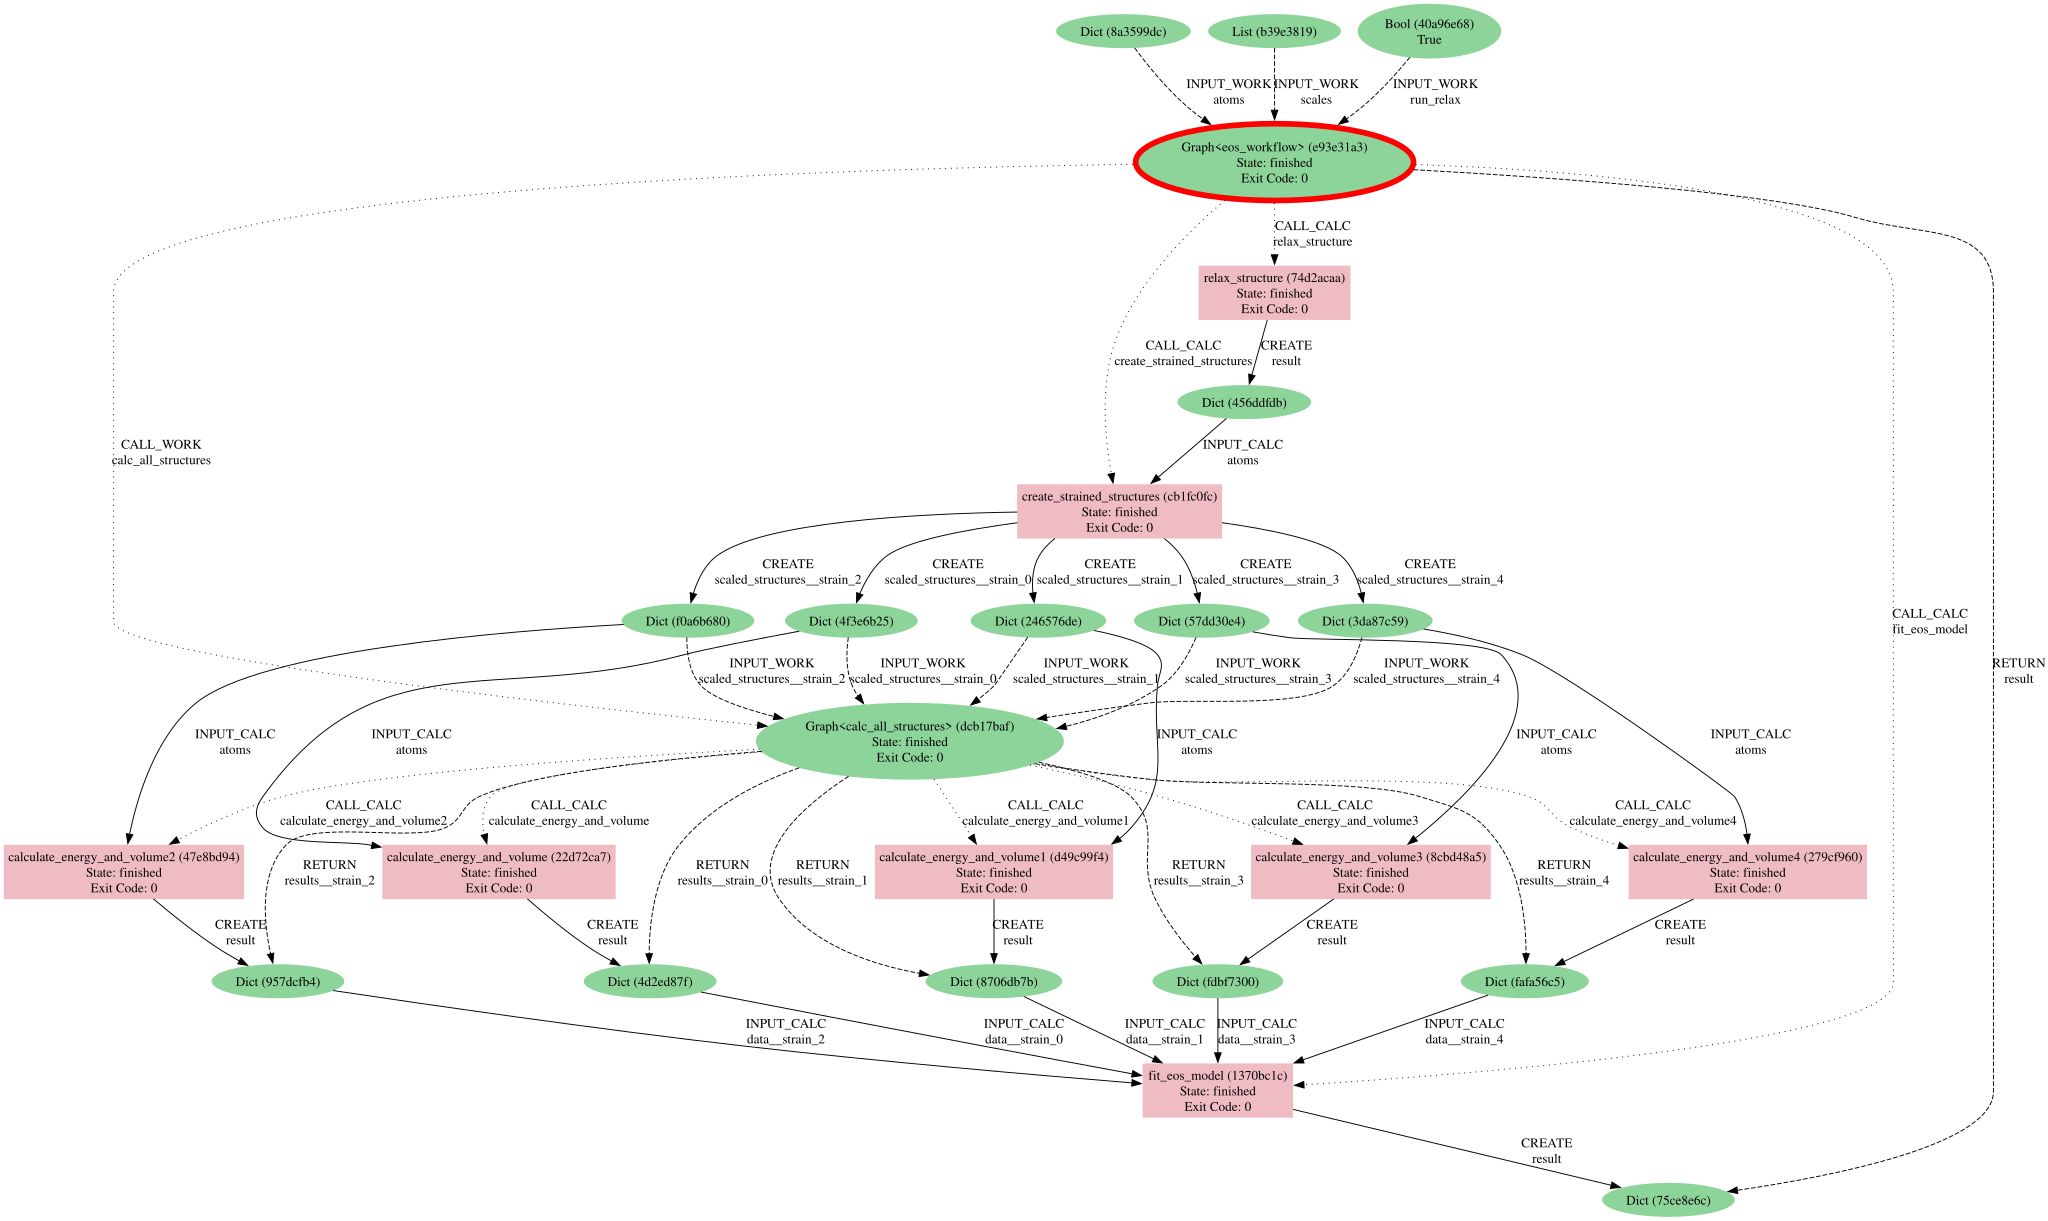

In [12]:
from node_graph_engine.engines.redun import RedunEngine

engine = RedunEngine("eos_workflow_redun")
results = engine.run(ng)
print("Fitted EOS parameters:", results)
engine.provenance_graph

<div class="alert alert-info"><h4>Note</h4><p>The [aiida-workgraph](https://aiida-workgraph.readthedocs.io/en/latest/tutorial/autogen/materials_science_ase.html#equation-of-state)  # noqa: E501
   project (built on top of Graph) ships the same Equation of State workflow
   described in this documentation and records provenance that is compatible
   with Graph Engine. This shared, decorator-driven approach lets different
   workflow systems exchange and analyse provenance without translation layers.</p></div>




## Conclusion
This example illustrated how to build a complex scientific workflow using
:mod:`node_graph`, featuring optional steps, dynamic namespaces, and nested
sub-workflows. The same workflow definition can be executed by multiple engines,
producing identical provenance for cross-comparison and analysis.

